In [1]:
library(tidyverse)
library(lubridate)
library(ggpubr)


source("../theme_ggplot_cfrna.R")
source("../functions.R")
gene_key = read.delim("../gencode.biotype.name.key.tsv")

── Attaching packages ─────────────────────────────────────── tidyverse 1.3.1 ──

✔ ggplot2 3.5.1     ✔ purrr   1.0.2
✔ tibble  3.2.1     ✔ dplyr   1.1.4
✔ tidyr   1.3.1     ✔ stringr 1.5.1
✔ readr   2.1.2     ✔ forcats 0.5.1

── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()


Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




## prepare metadata

In [2]:
#############################################
### METADATA
##################################

mdf = read.delim("../1_DATA/sample_meta_passQC.tsv") %>% filter(ORIGIN == "DFCI")
metrics = read.delim("../1_DATA/metrics_passQC.tsv") %>% unique()
decon = read.delim("../1_DATA/decon_passQC.tsv")

### remove 100 and 24
mdf = mdf %>% filter(!Record_ID %in% c("24"))

### add metrics and decon
mdf <- merge(mdf, metrics, by="sample_id")
mdf <- merge(mdf, decon, by="sample_id")

### factor timepoint
mdf = mdf %>% 
    mutate(timepoint = factor(timepoint, levels = EVENTS)) %>% 
    mutate(timepoint_sym = factor(timepoint_sym, levels = EVENTS_sym)) %>% 
    unique()

mdf$timepoint <- droplevels(mdf$timepoint)
mdf$timepoint_sym <- droplevels(mdf$timepoint_sym)

mdf = mdf %>% 
    mutate(expGroup = case_when(
                (timepoint != "HD" | is.na(timepoint) ) & !is.na(date_Lgvhd) ~ "GVHD+",
                (timepoint != "HD" | is.na(timepoint) ) & is.na(date_Lgvhd) ~ "GVHD-",
                timepoint == "HD"  ~ "Healthy Donor")) %>%
    mutate(expGroup = factor(expGroup, levels = c("Healthy Donor","GVHD-","GVHD+")))

## Timing

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Don't know how to automatically pick scale for object of type <difftime>.
Defaulting to continuous.
Don't know how to automatically pick scale for object of type <difftime>.
Defaulting to continuous.


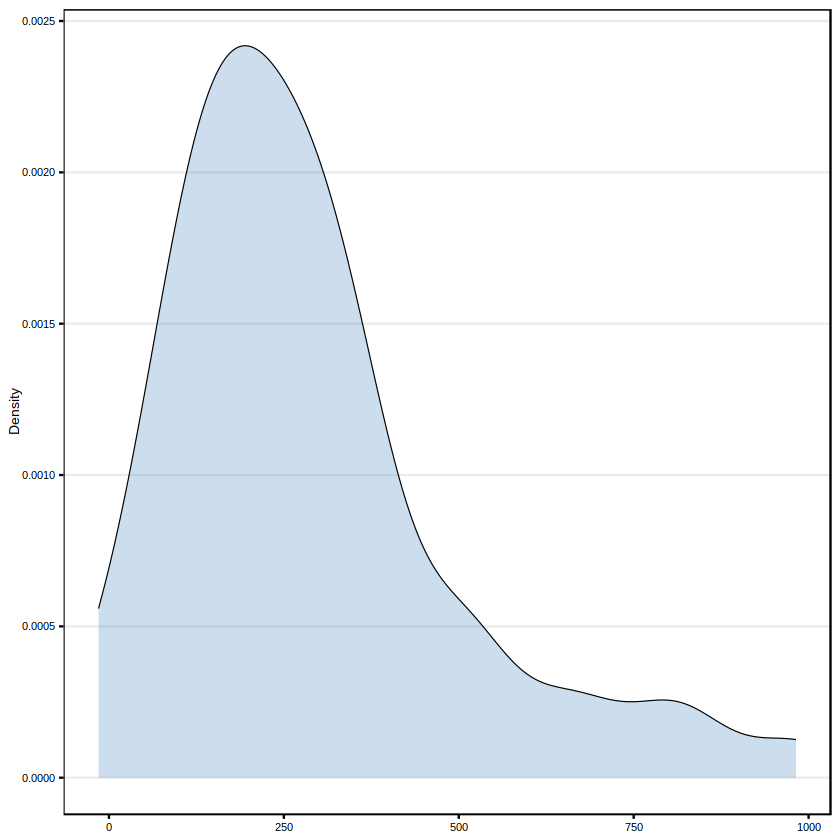

In [ ]:
set.seed(42)

timing_plt<-mdf %>%
  select(Record_ID, transplant_date, date_Lgvhd) %>%
  distinct() %>%
  mutate(
    Lgvhd_rel_trans = as.numeric(ymd(date_Lgvhd) - ymd(transplant_date))
  ) %>%
  filter(!is.na(Lgvhd_rel_trans)) %>%
  ggplot(aes(x = Lgvhd_rel_trans)) +
  geom_histogram(
    binwidth = 50,                        # adjust bin width as desired
    fill = COLORs[["GVHD+"]], 
    color = "black", 
    size = 0.25, 
    alpha = 0.5
  ) +
  # xlim(0, 1000) +
  geom_vline(xintercept = 90, linetype = "dashed", color = "black", size = 0.6) +
  geom_vline(xintercept = 180, linetype = "dashed", color = "black", size = 0.6) +
  scale_y_continuous(breaks = function(limits) seq(0, ceiling(limits[2]), by = 1)) +
  theme_cfrna_print() +
  theme(
    legend.position = "none",
    panel.grid.minor = element_blank(),
    panel.grid.major.x = element_blank(),
    strip.background = element_blank(),
    strip.text = element_blank(),
    axis.text.x = element_text(size = 6, angle = 45, hjust = 1)
  ) +
  labs(
    x = "Days post Transplant",
    y = "Number of Patients"
  )
ggsave("./figures/cGVHD_timing.pdf", width = 2.25, height = 2)


---
# pairwise

### select samples

In [4]:
TIME = c("HD", "E","1M","2M","3M","6M")
mdf_cghvd <- mdf %>% 
    filter(timepoint %in% TIME) %>% 
    ## DFCI filters
    ## remove samples with cGVHD
    filter(rel_cgvhd < 0 | is.na(rel_cgvhd) | ORIGIN == "MCC") %>% 
    mutate(expGroup = ifelse(timepoint %in% c("3M","6M"),"3-6M",as.character(timepoint))) %>% 
    mutate(expGroup = factor(expGroup, levels = c("HD","3-6M")))

table(mdf_cghvd$timepoint, !is.na(mdf_cghvd$date_cgvhd))

    
     FALSE TRUE
  HD    18    0
  PR     0    0
  D0     0    0
  E     35   37
  1M    35   39
  2M    30   38
  3M    38   45
  6M    34   30

### pairwise comparisons

In [108]:
EXP = "taper_start"
EXP = "3-6M"
# EXP = "6M"
# EXP = "3M"
# EXP = "1M"

### run wilcoxon tests
all_metrics = c(colnames(metrics),colnames(decon))
all_metrics = all_metrics[!all_metrics %in% c("sample_id","Record_ID","timepoint")]

all_res_wilcox = lapply(all_metrics, function(X) {

    g1= mdf_cghvd %>% 
        # filter(timepoint == EXP) %>%
        filter(expGroup == EXP) %>% 
        filter(is.na(date_cgvhd)) %>% pull(X) %>% as.numeric()
    g2= mdf_cghvd %>% 
        # filter(timepoint == EXP) %>% 
        filter(expGroup == EXP) %>% 
        filter(!is.na(date_cgvhd)) %>% pull(X) %>% as.numeric()

    FC= median(g2) / median(g1)
    res = suppressWarnings(wilcox.test(g1,g2))

    return(c(X=X, p=res$p.value, fc = FC)) }
    ) 
    
    
all_res_wilcox = all_res_wilcox %>%  do.call(rbind, .) %>% as.data.frame()

all_res_wilcox$fc = as.numeric(all_res_wilcox$fc)

all_res_wilcox %>% filter(fc > 1) %>% arrange(p) %>% head(10)
all_res_wilcox %>% filter(fc < 1) %>% arrange(p) %>% head(10)


,X,p,fc
,<chr>,<chr>,<dbl>
1,mature_conventional_dendritic_cell,0.0205984081498969,3.150254
2,mucus_secreting_cell_secretory_cell_tracheal_goblet_cell,0.0505951352920764,1.041652
3,repHistone_CPM,0.118841237826912,1.160373
4,thymocyte,0.126349633995963,1.579337
5,melanocyte,0.178129992769272,1.000786
6,nk_cell,0.22592878669343,1.618364
7,endothelial_cell,0.339492695786298,1.213770
8,platelet_decon,0.378023128674163,1.004735
9,platelet,0.378023128674163,1.004735


,X,p,fc
,<chr>,<chr>,<dbl>
1,acinar_cell_of_salivary_gland_myoepithelial_cell,0.00207958291063126,9.255357e-01
2,pancreatic_stellate_cell,0.00337461932841543,9.728405e-01
3,hepatocyte,0.0054316056437792,7.234987e-02
4,pulmonary_ionocyte,0.00906058994484855,5.557749e-06
5,pancreatic_ductal_cell,0.0100273362635509,9.512973e-01
6,kidney_epithelial_cell,0.0110849012060496,8.488589e-03
7,fibroblast_mesenchymal_stem_cell,0.0126486361810167,6.049397e-08
8,ciliated_epithelial_cell_epithelial_cell_of_uterus,0.016028603954132,9.615312e-01
9,pancreatic_acinar_cell,0.0247349692939026,9.303076e-01


In [7]:
all_metrics

[1] "avgDist_trajectory"                                                                                                                                                                                                                                          
 [2] "avgCorrelation_trajectory"                                                                                                                                                                                                                                   
 [3] "Alphatorquevirus_CPM"                                                                                                                                                                                                                                        
 [4] "Pegivirus_CPM"                                                                                                                                                                                                                                               
 [5] "neutrophil_activity"                                                                                                                                                                                                                                         
 [6] "lymphocyte_activity"                                                                                                                                                                                                                                         
 [7] "leukocyte_activity"                                                                                                                                                                                                                                          
 [8] "platelet_activity"                                                                                                                                                                                                                                           
 [9] "rbc_activity"                                                                                                                                                                                                                                                
[10] "monocyte_activity"                                                                                                                                                                                                                                           
[11] "basophil_activity"                                                                                                                                                                                                                                           
[12] "neutrophil_CBC"                                                                                                                                                                                                                                              
[13] "lymphocyte_CBC"                                                                                                                                                                                                                                              
[14] "leukocyte_CBC"                                                                                                                                                                                                                                               
[15] "platelet_CBC"                                                                                                                                                                                                                                                
[16] "rbc_CBC"                                                                                       

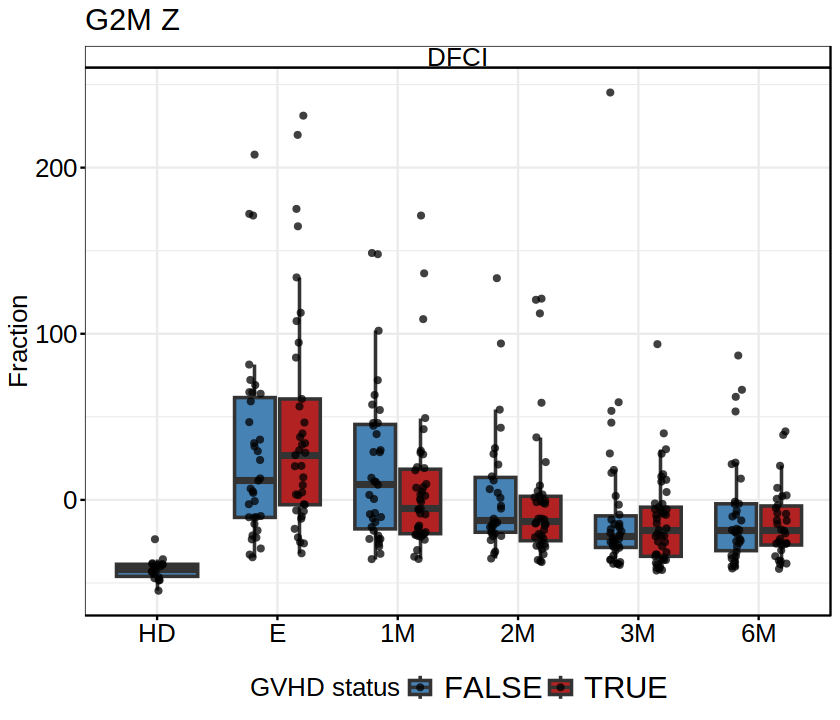

In [16]:
VAR = "mature_conventional_dendritic_cell"
VAR = "thymocyte"
VAR = "nk_cell"

VAR = "G2M_Z"


options(repr.plot.width=7, repr.plot.height=6)

mdf_cghvd %>% 
    ggplot(aes(x=timepoint, y=!!sym(VAR), fill =  !is.na(date_cgvhd))) +
    # ggplot(aes(x=expGroup, y=!!sym(VAR), fill =  !is.na(date_cgvhd))) +
    geom_boxplot(outlier.shape=NA,size= 0.75)+
    geom_point(position =  position_jitterdodge(jitter.height=0, 
                                                jitter.width=.1, 
                                                seed=42),
                size = 2, alpha = 0.75, stroke=NA)+
    theme_cfrna_slides()+
    labs(title = gsub("_"," ",VAR), y = "Fraction", x = "Timepoint", fill = "GVHD status")+
    theme(axis.title.x = element_blank(), 
        legend.position = "bottom",
        legend.text = element_text(size = 18))+
    # coord_cartesian(ylim = c(0,0.001))+
    ggh4x::facet_grid2(.~ORIGIN, scales = "free", independent = "y")+
    scale_fill_manual(values = c("FALSE" = "#4682B4", "TRUE" = "#B22222"))


---
# cGVHD - Decon

### Select samples

In [5]:
library(cowplot)
library(gridExtra)
library(scales)


TIME = c("HD","3M","6M")
mdf_cgvhd <- mdf %>%
    filter(timepoint %in% TIME) %>%
    filter(rel_Lgvhd < 0 | is.na(rel_Lgvhd))

table(mdf_cgvhd$expGroup, mdf_cgvhd$ORIGIN)



Attaching package: ‘cowplot’


The following object is masked from ‘package:ggpubr’:

    get_legend


The following object is masked from ‘package:lubridate’:

    stamp



Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine



Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




               
                DFCI
  Healthy Donor   18
  GVHD-           61
  GVHD+           81

### Wrangle data

In [6]:
CTs = c("mature_conventional_dendritic_cell","repHistone_CPM","nonrepHistone_CPM","nk_cell")
newCT = data.frame(cell_type = CTs,
                    cell_type_label = c("Dendritic cell",
                            "replication\nhistone transcripts",
                            "nonreplication\nhistone transcripts",
                            "nk cell\n")
                            )


decon_plt <- mdf_cgvhd[,c("sample_id", "timepoint", "expGroup","rel_transplant","ORIGIN","Record_ID",CTs)] %>% 
    reshape2::melt(id.vars = c("sample_id","timepoint","expGroup","rel_transplant","Record_ID","ORIGIN"), variable.name = "cell_type", value.name = "fraction")

decon_plt <- merge(decon_plt, newCT, by="cell_type") %>% 
    mutate(cell_type_label = factor(cell_type_label, levels = newCT$cell_type_label))

### Generate plots

In [7]:
NUM_TICKS = 3

label = "Dendritic cell"

### subset data and select y axis
plot_data <- decon_plt %>% filter(cell_type_label == label)
cell_y_range <- c(0,max(plot_data$fraction, na.rm = TRUE))
yticks <- pretty(cell_y_range, n = NUM_TICKS, min.n = 3)                                        # Adjust n for more or fewer ticks


### make plot
dend_plt = plot_data %>%
  filter(!is.na(timepoint)) %>%
  ggplot(aes(x = expGroup, y = fraction, fill = expGroup, color = expGroup)) +

  geom_boxplot(outlier.shape = NA, position = position_dodge(width = 0.8), width = 0.7, alpha = 0.25, size = 0.1) +

  geom_point(size = 1, alpha = 0.75, stroke=NA,
            position =  position_jitterdodge(jitter.height=0, 
                                              jitter.width=.5, 
                                              dodge.width = 0.8, 
                                              seed=42)
              )+
  theme_cfrna_print() +
  labs(y=label,title = label)+
  theme(
      plot.title = element_blank(),
      axis.title.x = element_blank(),
      axis.text.x = element_text(angle = 45, hjust = 1),
      panel.grid.major.x = element_blank()        # Remove major x gridlines
    )+
  scale_fill_manual(values = COLORs)+
  scale_color_manual(values = COLORs)


my_comparisons <- list( c("Healthy Donor", "GVHD-"), c("Healthy Donor", "GVHD+"), c("GVHD-", "GVHD+") )
dend_plt = dend_plt  + stat_compare_means(
      comparisons = my_comparisons,
      method = "wilcox.test",
      symnum.args = list(cutpoints = c(0, 0.0001, 0.001, 0.01, 0.1, Inf), symbols = c("****", "***", "**", "*", "ns")),
      size = 2,
      tip.length = 0,
       label.y = c(0.046,0.052,0.058)
      #  label.y = 0.045

      # vjust = .7,
      # hide.ns = TRUE,
      )

In [8]:
NUM_TICKS = 3

label = "nk cell\n"

### subset data and select y axis
plot_data <- decon_plt %>% filter(cell_type_label == label)
cell_y_range <- c(0,max(plot_data$fraction, na.rm = TRUE))
yticks <- pretty(cell_y_range, n = NUM_TICKS, min.n = 3)                                        # Adjust n for more or fewer ticks


### make plot
nk_plt = plot_data %>%
  filter(!is.na(timepoint)) %>%
  ggplot(aes(x = expGroup, y = fraction, fill = expGroup, color = expGroup)) +

  geom_boxplot(outlier.shape = NA, position = position_dodge(width = 0.8), width = 0.7, alpha = 0.25, size = 0.1) +

  geom_point(size = 1, alpha = 0.75, stroke=NA,
            position =  position_jitterdodge(jitter.height=0, 
                                              jitter.width=.5, 
                                              dodge.width = 0.8, 
                                              seed=42)
              )+
  theme_cfrna_print() +
  labs(y=label,title = label)+
  theme(
      plot.title = element_blank(),
      axis.title.x = element_blank(),
      axis.text.x = element_text(angle = 45, hjust = 1),
      panel.grid.major.x = element_blank()        # Remove major x gridlines
    )+
  scale_fill_manual(values = COLORs)+
  scale_color_manual(values = COLORs)

my_comparisons <- list( c("Healthy Donor", "GVHD-"), c("Healthy Donor", "GVHD+"), c("GVHD-", "GVHD+") )
nk_plt = nk_plt  + stat_compare_means(
      comparisons = my_comparisons,
      method = "wilcox.test",
      symnum.args = list(cutpoints = c(0, 0.0001, 0.001, 0.01, 0.1, Inf), symbols = c("****", "***", "**", "*", "ns")),
      size = 2,
      tip.length = 0,
      # vjust = .7,
      # hide.ns = TRUE,
      )

---
# DESEQ2 

In [3]:
suppressMessages(library(DESeq2))

In [4]:
TIME = c("3M","6M")
mdf_cgvhd_daa <- mdf %>% 
    filter(timepoint %in% TIME) %>% 
    ## remove samples with cGVHD
    filter(rel_Lgvhd < 0 | is.na(rel_Lgvhd)) %>% 
    mutate(expGroup = case_when(
                expGroup == "GVHD+" ~ "Pos",
                expGroup == "GVHD-" ~ "Neg",
                .default=expGroup
    )) 



### get counts
counts = read.delim("../1_DATA/counts_sQC_gAll_nRaw.tsv")
counts_daa = counts[,mdf_cgvhd_daa$sample_id]

counts_vst = read.delim("../1_DATA/counts_sQC_gAll_nVST.tsv")
counts_vst = counts_vst[,mdf_cgvhd_daa$sample_id]

### Run DESeq2

In [5]:
# ##------------------------------------
# ## Run DESeq
# dds <- DESeqDataSetFromMatrix(counts_daa,
#                                 colData = mdf_cgvhd_daa,
#                                 design = ~ timepoint + expGroup )

# # Normalize counts and estimate size factors
# dds <- estimateSizeFactors(dds)

# # Compute baseMean and filter genes
# baseMean_values <- rowMeans(counts(dds, normalized=TRUE))
# dds <- dds[baseMean_values > 5, ]

# dds <- DESeq(dds)


# dds %>% saveRDS("./outputs/DESEQ2_cgvhd.rds")

##------------------------------------
## Get Results
dds = readRDS("./outputs/DESEQ2_cgvhd.rds")
res <- results(dds, contrast=c("expGroup","Pos","Neg")) 

res_df <- res %>% data.frame()
res_df <- merge(res_df,gene_key, by.x=0, by.y="gene_id") %>% column_to_rownames(.,"Row.names")

##------------------------------------
## save for IPA
res_df %>% write.csv("./outputs/cGVHD-ipaIN.csv",quote=FALSE)

In [6]:
res_df %>% write.csv("./outputs/hsct_cfrna_DataS3.csv",quote=FALSE)

In [12]:
res_df %>% filter(padj < 0.1) %>% nrow()

[1] 106

### volcano

Warning message in geom_text_repel(size = 2, max.overlaps = Inf, min.segment.length = 0, :
“Ignoring unknown parameters: `fill`”
Warning message:
“Removed 7 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 7 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“Removed 7 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 7 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


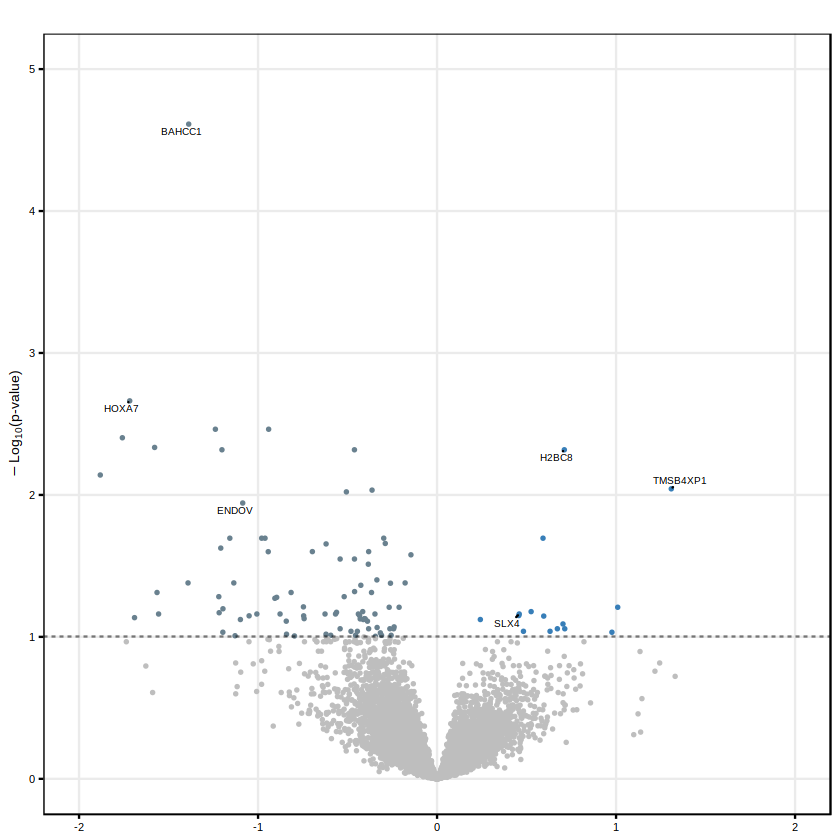

In [13]:
library(ggrepel)

PADJ_THRESH = 0.1
LFC_THRESH = 0.25

### extract results and label "up", "down", "notsig"
detable <- res_df %>%
    mutate(sig_dir = case_when(
        padj<PADJ_THRESH & log2FoldChange > 0 ~ "up",
        padj<PADJ_THRESH & log2FoldChange < 0  ~"down",
        .default = "notsig"))

GENEs = c("TMSB4XP1","SLX4","H2BC8","HOXA7","BAHCC1","ENDOV")
top_all = c(GENEs)
# top_all = c()
detable <- detable %>% mutate(delabel = ifelse(gene_name %in% top_all,gene_name,""))




# create plot
vol_plt <- detable %>% 
    # filter(baseMean > 50) %>% 
    # filter(gene_type == "protein_coding") %>% 
    filter(!is.na(padj)) %>%
    ggplot(aes(x=log2FoldChange, y=-log10(padj), color = sig_dir, label=delabel)) + #
    geom_point(size = 0.5) +
    geom_hline(yintercept = -log10(PADJ_THRESH), size = 0.5, alpha = 0.5, linetype="dashed")+
    # geom_vline(xintercept = c(-LFC_THRESH, LFC_THRESH), size = 0.5, alpha = 0.5, linetype="dashed") + 
    geom_text_repel(size = 2, 
        max.overlaps=Inf, 
        min.segment.length = 0, 
        color = "black", 
        fill="white",
        box.padding = 0.1
        # xlim = c(-Inf, Inf), ylim = c(-Inf, Inf)
        ) +
    theme_cfrna_print() +
    theme(
      panel.grid.minor.x = element_blank(),        # Remove major x gridlines
      axis.title.x = element_blank()
    )+
    xlim(-2,2)+ ylim(0,5)+
    labs(x = bquote(Log[2]*" Fold Change"), y= bquote(-Log[10]*"(p-value)"), title = "") +
    scale_color_manual(values = c("notsig"="grey","up"=COLORs[["GVHD+"]],"down"=COLORs[["GVHD-"]]))

vol_plt

WIDTH = 2
HEIGHT = 2

ggsave("figures/cGVHD_VOLCANO.plt.pdf", vol_plt, width = WIDTH, height = HEIGHT, dpi = 300)

### Combine

In [14]:
library(patchwork)


Attaching package: ‘patchwork’


The following object is masked from ‘package:cowplot’:

    align_plots




In [31]:
### COMBINE PLOTS

new_theme <- list(
    theme(axis.text.x = element_blank(),
        axis.title.x = element_text(size = 8, vjust = 5),
        axis.ticks.x = element_blank(),
        axis.title.y = element_blank())
)

YADD = 0.1
YADD_b = 0.05


gvhd_timing_final = timing_plt + 
    scale_y_continuous(limits = c(0-((0.004*YADD_b)),0.004*(1+YADD)), breaks = c(0,0.002,0.004))+
    labs(y="Density",x="Days Post Transplant")+
    theme(axis.title.x = element_text(size = 8, vjust = 0.75))+
    geom_vline(xintercept = 180, linetype = "dashed", color = "black", size = 0.3)+
    geom_vline(xintercept = 90, linetype = "dashed", color = "black", size = 0.3)+
    theme(plot.title = element_blank())

dend_plt_final = dend_plt+ 
    labs(x = "Dendritic Cell\nFraction") + 
    new_theme+
    scale_y_continuous( breaks = c(0, 0.03, 0.06))+
    coord_cartesian(ylim = c(0-(0.06*YADD_b),0.06*(1+YADD)))+
    theme(plot.title = element_blank())

nk_plt_final = nk_plt + 
    labs(x = "NK Cell\nFraction") + 
    new_theme+
    scale_y_continuous( breaks = c(0, 0.15, 0.3))+
    coord_cartesian(ylim = c(0-(0.3*YADD_b),0.3*(1+YADD)))+
    theme(plot.title = element_blank())

vol_plt = vol_plt+
    theme(axis.title.x = element_text(size = 8, vjust = 0.75))

plt_all = gvhd_timing_final + 
        plot_spacer() + 
        dend_plt_final + nk_plt_final + 
        plot_spacer() + 
        vol_plt +
        plot_layout(widths = c(1.69,0.37,1,1,0.45,2),nrow = 1)+
    theme(plot.title = element_blank())

# plt_al = dend_plt_final + nk_plt_final

# plt_all = timing_plt + dend_plt+nk_plt + vol_plt
# plt_all + plot_layout(widths = c(6,4,4, 6), nrow = 1)

WIDTH= 6.97
HEIGHT= 2

ggsave("./figures/cGVHD_toprow.pdf", width = WIDTH, height = HEIGHT)

Don't know how to automatically pick scale for object of type <difftime>.
Defaulting to continuous.
Warning message:
“Removed 7 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 7 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


In [ ]:
# ### COMBINE PLOTS

# new_theme <- list(
#     theme(axis.text.x = element_blank(),
#         axis.title.x = element_text(size = 8, vjust = 5),
#         axis.ticks.x = element_blank(),
#         axis.title.y = element_blank())
# )

# YADD = 0.1
# YADD_b = 0.05


# gvhd_timing_final = timing_plt + 
#     scale_y_continuous(limits = c(0-((0.004*YADD_b)),0.004*(1+YADD)), breaks = c(0,0.002,0.004))+
#     labs(y="Density",x="Days Post Transplant")+
#     theme(axis.title.x = element_text(size = 8, vjust = 0.75))+
#     geom_vline(xintercept = 180, linetype = "dashed", color = "black", size = 0.3)+
#     geom_vline(xintercept = 90, linetype = "dashed", color = "black", size = 0.3)+
#     theme(plot.title = element_blank())

# dend_plt_final = dend_plt+ 
#     labs(x = "Dendritic Cell\nFraction") + 
#     new_theme+
#     scale_y_continuous( breaks = c(0, 0.03, 0.06))+
#     coord_cartesian(ylim = c(0-(0.06*YADD_b),0.06*(1+YADD)))+
#     theme(plot.title = element_blank())

# nk_plt_final = nk_plt + 
#     labs(x = "NK Cell\nFraction") + 
#     new_theme+
#     scale_y_continuous( breaks = c(0, 0.15, 0.3))+
#     coord_cartesian(ylim = c(0-(0.3*YADD_b),0.3*(1+YADD)))+
#     theme(plot.title = element_blank())

# vol_plt = vol_plt+
#     theme(axis.title.x = element_text(size = 8, vjust = 0.75))

# plt_all = gvhd_timing_final + 
#         plot_spacer() + 
#         dend_plt_final + nk_plt_final + 
#         plot_spacer() + 
#         vol_plt +
#         plot_layout(widths = c(1.75,0.1,1,1,0.1,2),nrow = 1)+
#     theme(plot.title = element_blank())

# # plt_al = dend_plt_final + nk_plt_final

# # plt_all = timing_plt + dend_plt+nk_plt + vol_plt
# # plt_all + plot_layout(widths = c(6,4,4, 6), nrow = 1)

# WIDTH= 6.5
# HEIGHT= 2

# ggsave("./figures/cGVHD_toprow.pdf", width = WIDTH, height = HEIGHT)

Don't know how to automatically pick scale for object of type <difftime>.
Defaulting to continuous.


Warning message:
“Removed 7 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 7 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


### Gene counts

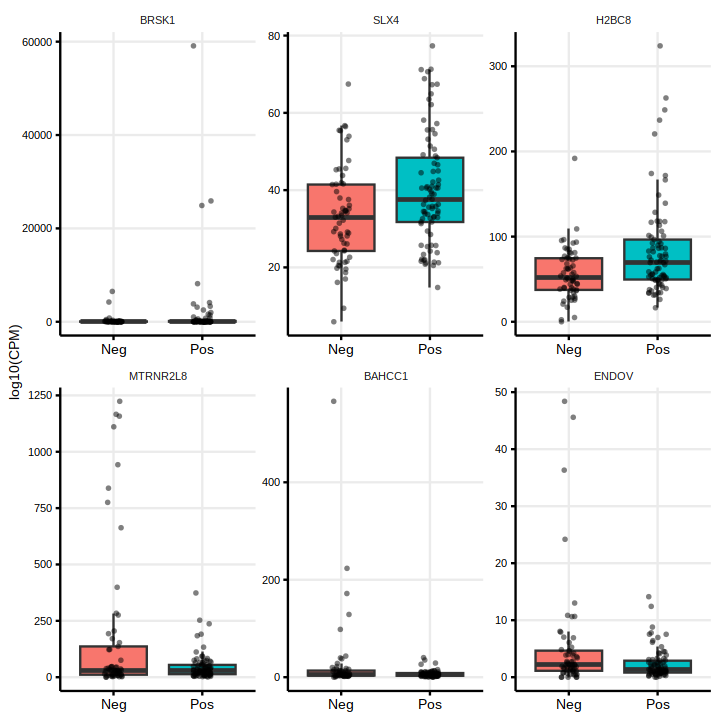

In [ ]:

GENEs = c("DPYSL2","MYO10","DLC1","STRADB","BPGM","DCAF12")


GENEs = c("BRSK1","SLX4","H2BC8","MTRNR2L8","BAHCC1","ENDOV")




GENEIDS = gene_key %>% filter(gene_name %in% GENEs) %>% pull(gene_id)

### Normalize counts
CNTS = edgeR::cpm(counts_daa)
# CNTs = counts(dds,normalized = TRUE)

### Combine counts with metadata
cnt_df = merge(mdf_cgvhd_daa %>% select(sample_id, date_cgvhd, expGroup, timepoint), 
        data.frame(t(CNTS[GENEIDS,])),
        by.x="sample_id",by.y=0) %>% 
    reshape2::melt(id.vars = c("sample_id","date_cgvhd", "expGroup","timepoint"), variable.name = "gene_id",value.name = "counts")

### Add gene names for plotting
cnt_df = merge(cnt_df, gene_key, by.x="gene_id", by.y="gene_id") %>% 
    mutate(gene_name = factor(gene_name, levels = GENEs))

### Make plot
cnt_df %>% 
    ggplot(aes(x=expGroup, y=counts, fill = expGroup))+
    geom_boxplot(outlier.shape = NA) +
    geom_point(position =  position_jitterdodge(jitter.height=0, 
                                                jitter.width=.2, 
                                                seed=42),
                size = 1.3, alpha = 0.5, stroke=NA)+
    theme_cfrna_print()+
    labs(y = "log10(CPM)")+
    theme(
        axis.text.x = element_text(size = 8),
        axis.title.x = element_blank(),
        panel.border = element_blank(),                  # Remove all borders initially
        axis.line = element_line(),                      # Add back the bottom and left lines
        axis.line.x.top = element_blank(),               # Ensure top border is removed
        axis.line.y.right = element_blank(),             # Ensure right border is removed
        panel.grid.minor.y = element_blank()             # Remove minor gridlines
        )+
    # scale_fill_manual(values = COLORs)+
    facet_wrap(~gene_name, scales = "free")+
    theme(strip.text = element_text(size = 6, vjust = 1),
        strip.background = element_blank())

# ### Save
# WIDTH = 2.5
# HEIGHT= 1.7

# ggsave("figures/aGVHD_EGenes.pdf", width=WIDTH, height=HEIGHT, units="in")

---
# Modeling - CPM TMM

### load data

In [ ]:
TIME = c("3M","6M")
mdf_cgvhd_daa <- mdf %>% 
    filter(ORIGIN == "DFCI") %>%
    filter(timepoint %in% TIME) %>% 
    filter(rel_Lgvhd < 0 | is.na(rel_Lgvhd)) %>% 
    mutate(expGroup = ifelse(!is.na(date_Lgvhd),"Pos","Neg")) 

# ### load counts
# counts = read.delim("../1_DATA/counts_sQC_gAll_nRaw.tsv")[,mdf_cgvhd_daa$sample_id]


# ### save outputs to run in python
# library(edgeR)

# dge = DGEList(counts = counts)
# dge = calcNormFactors(dge, method = "TMM")
# cpm_values = cpm(dge, log = TRUE)

cpm_values = read.delim("/fs/cbsuvlaminck5/workdir/gfa32/hsct_new/1_DATA/corrected_expr_platelet.tsv")[,]

cpm_values %>% write.csv("./modeling/modeling_counts_cpm_tmm_log.csv", row.names=TRUE, quote=FALSE)
mdf_cgvhd_daa %>% write.csv("./modeling/modeling_metadata.csv",row.names=FALSE,quote=FALSE)

Loading required package: limma



In [5]:
table(mdf_cgvhd_daa$expGroup)


Neg Pos 
 61  81 

### load outputs

In [6]:
scores = read.csv("./modeling/classifier_scores.csv") 
scores_df_all = merge(mdf_cgvhd_daa, scores, by="sample_id") 
scores_df = scores_df_all %>% 
    filter(iteration == 9)

scores_df %>% head()

,sample_id,Record_ID,date,timepoint,SCALE_qubit,sample_group,all_comps,transplant_date,date_taper_start,date_taper_end,⋯,club_cell_type_i_pneumocyte,pulmonary_ionocyte,pancreatic_pp_cell,pancreatic_delta_cell,duodenum_glandular_cell,thymocyte,expGroup,iteration,train_or_test,classifier_score
,<chr>,<chr>,<chr>,<fct>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>,<dbl>
1,gvhd_hct_cfrna_102_bp61x61,19,2018-12-14,3M,2.686183e-10,COMP,_relapse,2018-08-28,NA,NA,⋯,1.701289e-05,1.204271e-04,3.585138e-04,5.579272e-20,5.385259e-20,1.280994e-03,Neg,9,train,0.0005813387
2,gvhd_hct_cfrna_103_bp61x61,29,2018-12-19,3M,5.610784e-10,COMP,_cgvhd_bkvd_bkvr,2018-09-18,NA,NA,⋯,9.134975e-20,9.634701e-20,3.979777e-04,6.605042e-20,5.350056e-20,1.018706e-02,Pos,9,train,0.9994678900
3,gvhd_hct_cfrna_111_bp61x61,14,2019-02-07,6M,2.177556e-10,COMP,_relapse_agvhd,2018-08-08,NA,NA,⋯,8.680969e-20,1.228096e-04,9.376138e-20,6.523471e-20,5.596802e-20,6.279812e-03,Neg,9,test,0.2973047051
4,gvhd_hct_cfrna_133_bp61x61,72,2019-05-21,3M,3.504753e-10,COMP,_agvhd_bkvd_bkvr,2019-02-21,NA,NA,⋯,7.181860e-04,8.829015e-04,1.084574e-03,6.277321e-20,5.795487e-20,4.108406e-05,Neg,9,train,0.0003910540
5,gvhd_hct_cfrna_143_bp61x61,50,2019-03-06,3M,1.851250e-09,COMP,_cgvhd_bkvr,2018-12-04,NA,NA,⋯,9.538353e-20,8.563530e-05,6.462632e-04,5.233794e-20,2.076110e-06,2.117498e-04,Pos,9,train,0.9992680221
6,gvhd_hct_cfrna_144_bp61x61,21,2019-03-01,6M,5.264282e-10,COMP,_agvhd,2018-08-29,NA,NA,⋯,9.209225e-20,1.304309e-03,1.527634e-03,5.221778e-06,1.251248e-05,1.401601e-02,Neg,9,train,0.0005966586


### All performances

In [7]:
suppressMessages(library(pROC))

all_res = list()
for(i in 0:100) {

    train_mdf = scores_df_all %>% filter(iteration == i) %>% filter(train_or_test == "train")
    roc_train <- suppressMessages(roc(response = train_mdf$expGroup, predictor = train_mdf$classifier_score,
                    percent=TRUE,
                    ci=TRUE, 
                    boot.n=10000, boot.stratified=TRUE,
                    print.auc=TRUE,
                    print.thres="best",
                    print.thres.best.method="youden"))

    test_mdf = scores_df_all %>% filter(iteration == i) %>% filter(train_or_test == "test")
    roc_test <- suppressMessages(roc(response = test_mdf$expGroup, predictor = test_mdf$classifier_score,
                    percent=TRUE,
                    ci=TRUE, 
                    boot.n=10000, boot.stratified=TRUE,
                    print.auc=TRUE,
                    print.thres="best",
                    print.thres.best.method="youden"))

    ##------------------------------------
    ## get roc values
    ##------------------------------------

    all_roc = c("iteration" = i, "train" = roc_train$auc, "test" = roc_test$auc)

    all_res[[i+1]] = all_roc

}
all_res_df = do.call("rbind",all_res) %>% data.frame()

all_res_df %>% head

Warning message in ci.auc.roc(roc, ...):
“ci.auc() of a ROC curve with AUC == 1 is always 1-1 and can be misleading.”
Warning message in ci.auc.roc(roc, ...):
“ci.auc() of a ROC curve with AUC == 1 is always 1-1 and can be misleading.”
Warning message in ci.auc.roc(roc, ...):
“ci.auc() of a ROC curve with AUC == 1 is always 1-1 and can be misleading.”
Warning message in ci.auc.roc(roc, ...):
“ci.auc() of a ROC curve with AUC == 1 is always 1-1 and can be misleading.”
Warning message in ci.auc.roc(roc, ...):
“ci.auc() of a ROC curve with AUC == 1 is always 1-1 and can be misleading.”
Warning message in ci.auc.roc(roc, ...):
“ci.auc() of a ROC curve with AUC == 1 is always 1-1 and can be misleading.”
Warning message in ci.auc.roc(roc, ...):
“ci.auc() of a ROC curve with AUC == 1 is always 1-1 and can be misleading.”
Warning message in ci.auc.roc(roc, ...):
“ci.auc() of a ROC curve with AUC == 1 is always 1-1 and can be misleading.”
Warning message in ci.auc.roc(roc, ...):
“ci.auc() of a 

,iteration,train,test
,<dbl>,<dbl>,<dbl>
1,0,100,75.98039
2,1,100,69.11765
3,2,100,82.35294
4,3,100,62.74510
5,4,100,82.35294
6,5,100,90.68627


In [12]:
all_res_df %>% 
    mutate(test = test / 100) %>% head

,iteration,train,test
,<dbl>,<dbl>,<dbl>
1,0,100,0.7598039
2,1,100,0.6911765
3,2,100,0.8235294
4,3,100,0.6274510
5,4,100,0.8235294
6,5,100,0.9068627


Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”


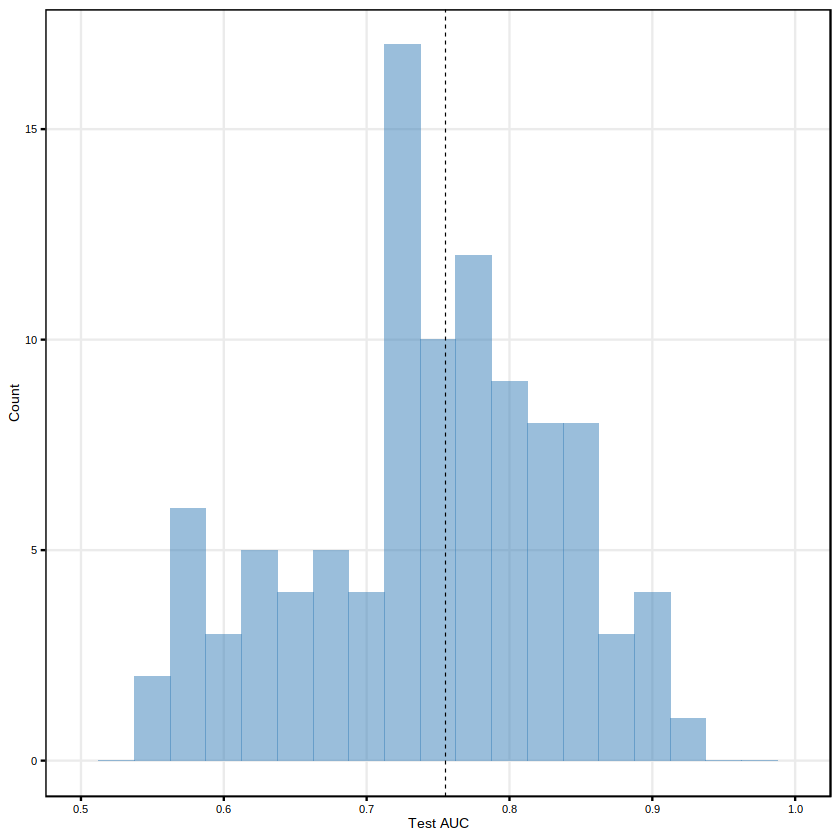

In [17]:
HIST_AUC_plt = all_res_df %>% 
    mutate(test = test / 100) %>% 
    ggplot(aes(x=test))+
    geom_histogram(binwidth = 2.5/100, fill = COLORs[["GVHD+"]], color = NA, alpha = 0.5)+
    geom_vline(xintercept = median(all_res_df$test)/100, linetype = "dashed",  size = 0.25)+
    theme_cfrna_print()+
    labs(x="Test AUC",y="Count")+
    xlim(0.5,1)

HIST_AUC_plt

### ROC

Warning message in ci.auc.roc(roc, ...):
“ci.auc() of a ROC curve with AUC == 1 is always 1-1 and can be misleading.”


Area under the curve: 100%
Area under the curve: 75.49%


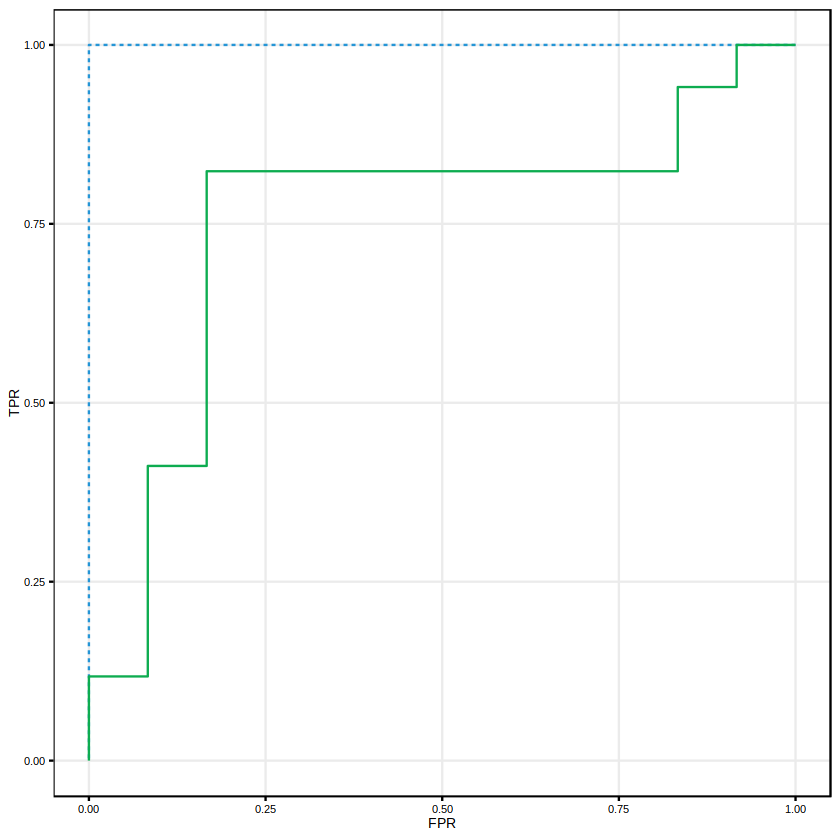

In [18]:
suppressMessages(library(pROC))
##------------------------------------
## ROC plot
##------------------------------------

train_mdf = scores_df %>% filter(train_or_test == "train")
roc_train <- suppressMessages(roc(response = train_mdf$expGroup, predictor = train_mdf$classifier_score,
                percent=TRUE,
                ci=TRUE, 
                boot.n=10000, boot.stratified=TRUE,
                print.auc=TRUE,
                print.thres="best",
                print.thres.best.method="youden"))

test_mdf = scores_df %>% filter(train_or_test == "test")
roc_test <- suppressMessages(roc(response = test_mdf$expGroup, predictor = test_mdf$classifier_score,
                percent=TRUE,
                ci=TRUE, 
                boot.n=10000, boot.stratified=TRUE,
                print.auc=TRUE,
                print.thres="best",
                print.thres.best.method="youden"))

##------------------------------------
## get roc values
##------------------------------------

train_roc <- data.frame("sensitivity" = roc_train$sensitivities,
                        "specificity" = roc_train$specificities,
                       "set" = "train")

test_roc <- data.frame("sensitivity" = roc_test$sensitivities,
                        "specificity" = roc_test$specificities,
                       "set" = "test")


all_roc <- do.call("rbind",list(train_roc, test_roc)) %>%
    mutate(FPR = 1-(as.numeric(specificity)/100),
          TPR = as.numeric(sensitivity)/100)


## malke plot

auc_plt = all_roc %>% 
    mutate(set = factor(set,levels = c("train","validate","test"))) %>% 
    ggplot(aes(x= FPR, y= TPR, group = set, linetype = set, color = set))+
    geom_path()+
    theme_cfrna_print()+
    theme(
                panel.grid.minor.y = element_blank(),       # Remove minor gridlines
                strip.text = element_text(size = 8),
        )+
    scale_linetype_manual(values = c("train"="dashed","test"="solid"))+
    scale_color_manual(values = c("train"="#2495D6","test"="#0DAC50"))+
    theme(panel.grid.minor  = element_blank()) 
    
auc_plt

WIDTH = 2.1
HEIGHT = 2
ggsave("./figures/cGVHD_ROC.pdf", width = WIDTH, height = HEIGHT)

print(roc_train$auc)
print(roc_test$auc)

## explore features

In [19]:
features = read.csv("./modeling/selected_features.csv")
features_df = merge(features, gene_key, by.x="feature", by.y="gene_id")
features_df %>% head


,feature,iteration,coefficient,gene_name,gene_type
,<chr>,<int>,<dbl>,<chr>,<chr>
1,ENSG00000000460.17,83,0.0192146894,C1orf112,protein_coding
2,ENSG00000000460.17,61,0.0100464692,C1orf112,protein_coding
3,ENSG00000000460.17,24,0.0109261086,C1orf112,protein_coding
4,ENSG00000000460.17,34,0.0162561087,C1orf112,protein_coding
5,ENSG00000000460.17,81,0.0001525745,C1orf112,protein_coding
6,ENSG00000000460.17,0,0.0387544636,C1orf112,protein_coding


In [20]:
features_df %>% 
    group_by(iteration) %>% summarize(n=n()) %>% 
    pull(n) %>% summary()

features_df %>% 
    group_by(feature) %>% summarize(n=n()) %>% 
    pull(n) %>% summary()

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   54.0   215.0   446.0   427.4   626.0   799.0 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   1.00    1.00    3.00   11.15   12.00  101.00 

In [21]:
top_features = features_df %>% 
    group_by(feature,gene_name) %>% 
    summarize(n=n(),mean_c = mean(coefficient), max_c = max(coefficient), min_c = min(coefficient)) %>% 
    arrange(desc(n),max_c) %>% 
    head(15) 

order = top_features$gene_name
top_features$gene_name = factor(top_features$gene_name, levels = rev(order))


`summarise()` has grouped output by 'feature'. You can override using the
`.groups` argument.


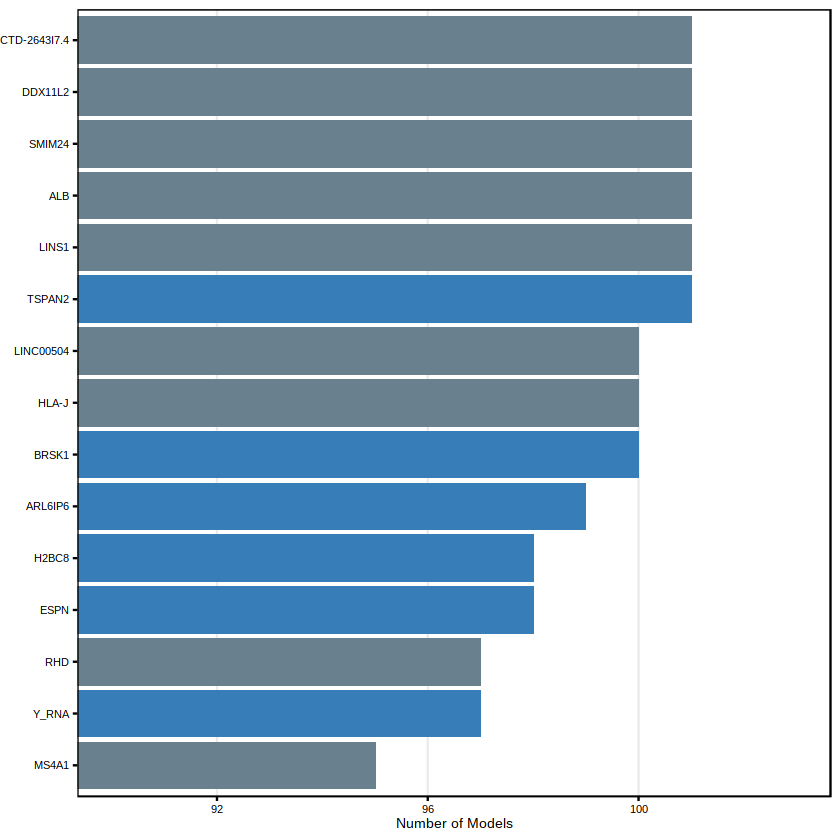

In [22]:
ft_plt = top_features %>% 
    mutate(dir = ifelse(mean_c > 0,"up","down")) %>%
    ggplot(aes(x=n, y=gene_name, fill = dir))+
    geom_bar(stat="identity")+
    theme_cfrna_print()+
    labs(x="Number of Models")+
    theme(axis.title.y=element_blank(),
            strip.text = element_text(size = 8),
            panel.grid.major.y = element_blank()
        )+
    coord_cartesian(xlim = c(90,103))+
    scale_fill_manual(values = c("down"=COLORs[['GVHD-']],"up"=COLORs[['GVHD+']]))

ft_plt

WIDTH= 2.1
HEIGHT= 2
ggsave("./figures/cGVHD_FEATURES.pdf", width = WIDTH, height = HEIGHT)

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”


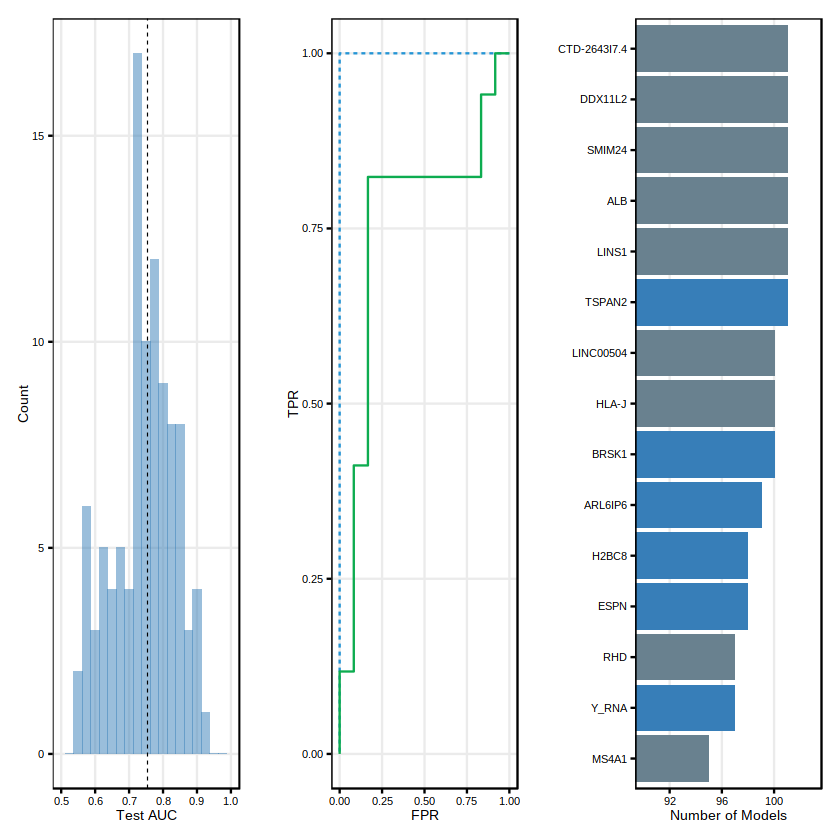

In [23]:
## combine

library(patchwork)

plt_all = HIST_AUC_plt + 
        plot_spacer() + 
        auc_plt + 
        plot_spacer() + 
        ft_plt + 
        plot_layout(widths = c(1.5,0.1,1.5,0.1,1.5),nrow = 1)

plt_all

ggsave("./figures/cGVHD_MODELING.pdf", plt_all, width = 6.5, height = 2)

## KM Curve

In [50]:
library(survminer)
library(lubridate)

Loading required package: ggpubr


Attaching package: ‘ggpubr’


The following object is masked from ‘package:cowplot’:

    get_legend




In [37]:
scores_df %>% colnames

[1] "sample_id"                                                                                                                                                                                                                                                   
  [2] "Record_ID"                                                                                                                                                                                                                                                   
  [3] "date"                                                                                                                                                                                                                                                        
  [4] "ORIGIN"                                                                                                                                                                                                                                                      
  [5] "timepoint"                                                                                                                                                                                                                                                   
  [6] "transplant_date"                                                                                                                                                                                                                                             
  [7] "rel_transplant"                                                                                                                                                                                                                                              
  [8] "date_cgvhd"                                                                                                                                                                                                                                                  
  [9] "date_agvhd"                                                                                                                                                                                                                                                  
 [10] "rel_agvhd"                                                                                                                                                                                                                                                   
 [11] "rel_cgvhd"                                                                                                                                                                                                                                                   
 [12] "rel_drug"                                                                                                                                                                                                                                                    
 [13] "PredEqui_01"                                                                                                                                                                                                                                                 
 [14] "avgCorrelation_trajectory"                                                                                                                                                                                                                                   
 [15] "Alphatorquevirus_CPM"                                                                                                                                                                                                                                        
 [16] "Pegivirus_CPM"                                                                  

In [38]:
km_df = scores_df %>% 
    filter(train_or_test == "test") %>%
    select(sample_id, Record_ID, rel_cgvhd, expGroup, classifier_score) %>% 
    mutate(rel_cgvhd = -rel_cgvhd) %>% 
    mutate(quant = ifelse(classifier_score <0.5, "Low","High"))

# km_df = scores_df %>% 
#     select(sample_id, Record_ID, rel_cgvhd, expGroup, classifier_score, mature_conventional_dendritic_cell) %>% 
#     mutate(rel_cgvhd = -rel_cgvhd) %>% 
#     mutate(quant = ifelse(mature_conventional_dendritic_cell <0.0034667, "Low","High"))

# Replace NA in failure_days with an appropriate censoring indicator
km_df$censor = ifelse(is.na(km_df$rel_cgvhd),0,1)

# Replace NA in failure_days with some large value (to ensure censored individuals are included in the survival calculation):
MAX_DAYS <- max(km_df$rel_cgvhd, na.rm = TRUE)
km_df$rel_cgvhd[is.na(km_df$rel_cgvhd)] <- MAX_DAYS + 100

# Create the survival object
surv_obj <- survival::Surv(time = km_df$rel_cgvhd, event = km_df$censor)

# Fit the survival curve, split by the 'quant' group
fit <- survival::survfit(surv_obj ~ quant, data = km_df)

# Plot the KM curve with censoring information
km_plt <- ggsurvplot(fit, data = km_df, 
           legend.title = "Classifier Score:", 
           legend.labs = c("Low",  "High"),
           xlab = "Days to cGVHD", 
           ylab = "Survival Probability",
           conf.int = TRUE,
           censor = TRUE,          # Show censoring marks
           pval = FALSE, 
           risk.table = FALSE,      # Add risk table below the plot
           xlim = c(0,MAX_DAYS+100),
           ggtheme = theme_cfrna_print())

ggsave("./figures/KM_curve_MODEL.png", km_plt$plot, width = 3, height = 3, units = "in")

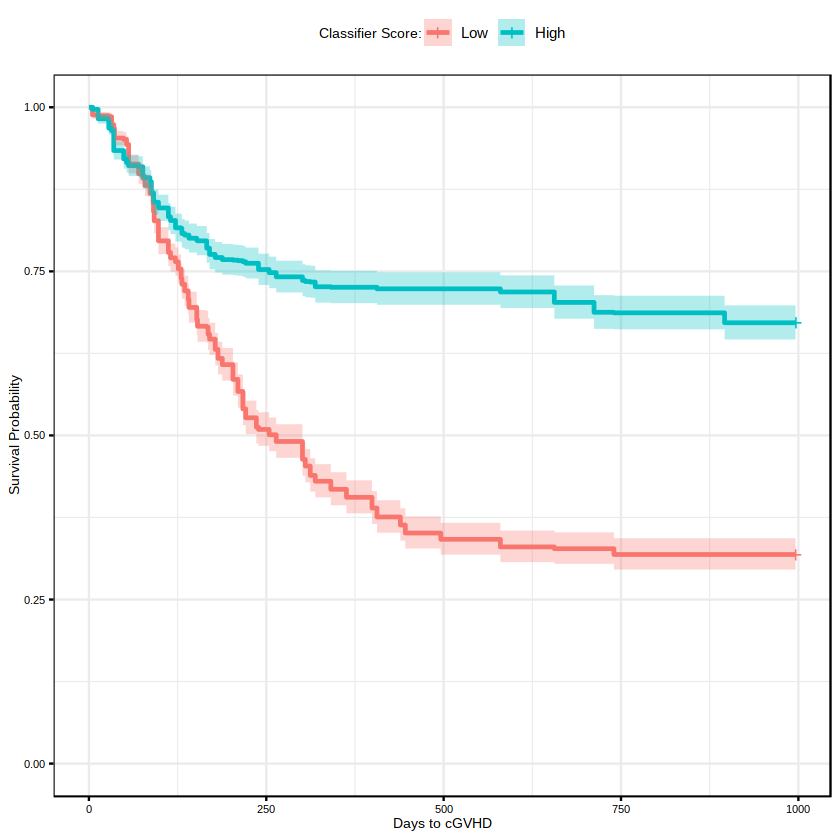

In [39]:
km_plt

---
---
## ALT?

In [4]:
TIME = c("3M","6M","taper_start","taper_end")
mdf_cgvhd_daa <- mdf %>% 
    filter(timepoint %in% TIME) %>% 
    filter(rel_cgvhd < 0 | is.na(rel_cgvhd) | ORIGIN == "MCC") %>% 
    mutate(expGroup = ifelse(!is.na(date_cgvhd),"Pos","Neg")) 

### load counts
counts = read.delim("../1_DATA/counts_sQC_gAll_nRaw.tsv")[,mdf_cgvhd_daa$sample_id]


### save outputs to run in python
library(edgeR)

dge = DGEList(counts = counts)
dge = calcNormFactors(dge, method = "TMM")
cpm_values = cpm(dge, log = TRUE)

cytology = read.csv("/workdir/cjl332/HCT_DFCI/cfRNA_data/cleaned_clinical_data/cytology_data.csv") %>% 
    select(Record_ID, Event_Name, blood_ALT, blood_AST) %>% 
    mutate(timepoint = case_when(
            Event_Name == "Month 3                 " ~ "3M",
            Event_Name == "Month 6                 " ~ "6M",
            .default = NA_character_            
    )) %>%
    filter(!is.na(timepoint))

mdf_cy = merge(mdf_cgvhd_daa, cytology, by=c("Record_ID","timepoint"), all.x=TRUE) %>% 
    mutate(blood_ALT = ifelse(blood_ALT == "NR",NA,as.numeric(blood_ALT)),
            blood_AST = ifelse(blood_AST == "NR",NA,as.numeric(blood_AST)))

mdf_cy %>% head

Warning message:
“There were 2 warnings in `mutate()`.
The first warning was:
ℹ In argument: `blood_ALT = ifelse(blood_ALT == "NR", NA,
  as.numeric(blood_ALT))`.
Caused by warning in `ifelse()`:
! NAs introduced by coercion
ℹ Run `dplyr::last_dplyr_warnings()` to see the 1 remaining warning.”


,Record_ID,timepoint,sample_id,date,SCALE_qubit.x,sample_group,all_comps,transplant_date,date_taper_start,date_taper_end,⋯,club_cell_type_i_pneumocyte,pulmonary_ionocyte,pancreatic_pp_cell,pancreatic_delta_cell,duodenum_glandular_cell,thymocyte,expGroup,Event_Name,blood_ALT,blood_AST
,<chr>,<fct>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>
1,101,3M,gvhd_hct_cfrna_571_bp61x61,2019-11-18,8.341471e-09,COMP,_agvhd,2019-08-20,NA,NA,⋯,2.225766e-09,3.942546e-05,5.343876e-04,5.920639e-20,7.046398e-06,0.006302962,Neg,Month 3,19,21
2,101,6M,gvhd_hct_cfrna_551_bp61x61,2020-03-04,2.975464e-09,COMP,_agvhd,2019-08-20,NA,NA,⋯,9.279371e-06,1.691787e-04,3.536867e-04,5.570700e-20,5.338758e-20,0.012534531,Neg,Month 6,44,29
3,102,3M,hct_cfrna_352_bp61x61,2019-11-20,8.837382e-10,COMP,_relapse_graftfail_bkvd_bkvr,2019-08-21,NA,NA,⋯,8.173834e-20,9.516673e-20,1.419016e-04,7.599778e-20,7.118418e-07,0.017710728,Pos,Month 3,26,20
4,102,6M,hct_cfrna_324_bp61x61,2020-02-26,8.138021e-10,COMP,_relapse_graftfail_bkvd_bkvr,2019-08-21,NA,NA,⋯,1.630465e-05,3.890706e-05,7.250159e-04,5.903874e-20,1.229830e-05,0.011609896,Pos,Month 6,34,30
5,103,3M,gvhd_hct_cfrna_572_bp61x61,2020-01-07,3.077189e-09,COMP,_cgvhd_agvhd_bkvr,2019-10-11,NA,NA,⋯,8.947946e-20,9.091540e-20,1.865179e-04,7.250971e-20,6.069679e-06,0.005249402,Pos,Month 3,30,NA
6,104,3M,hct_cfrna_376_bp61x61,2019-12-18,2.148946e-09,REF,,2019-09-19,NA,NA,⋯,8.143150e-20,8.642590e-20,9.151248e-05,5.566442e-20,5.127119e-20,0.010143718,Pos,Month 3,18,14


In [ ]:
GENEs = c("ALB")


GENEIDS = gene_key %>% filter(gene_name %in% GENEs) %>% pull(gene_id)

### Normalize counts
CNTS = cpm_values
CNTS = 

### Combine counts with metadata
cnt_df = merge(mdf_cy %>% select(sample_id, date_cgvhd, expGroup, timepoint, blood_ALT), 
        data.frame(t(CNTS[GENEIDS,,drop=FALSE])),
        by.x="sample_id",by.y=0) %>% 
    reshape2::melt(id.vars = c("sample_id","date_cgvhd", "expGroup","timepoint", "blood_ALT"), variable.name = "gene_id",value.name = "counts")

### Add gene names for plotting
cnt_df = merge(cnt_df, gene_key, by.x="gene_id", by.y="gene_id") %>% 
    mutate(gene_name = factor(gene_name, levels = GENEs))


In [6]:
ALT_df = cnt_df %>% 
    select(sample_id, expGroup, timepoint, blood_ALT) %>% 
    mutate(measurement = "blood ALT") %>% rename(value = blood_ALT)
ALB_df = cnt_df %>% 
    select(sample_id, expGroup, timepoint, counts) %>%
    mutate(measurement = "cfRNA ALB") %>% rename(value = counts)

plot_df = rbind(ALT_df,ALB_df)

plot_df %>% head

,sample_id,expGroup,timepoint,value,measurement
,<chr>,<chr>,<fct>,<dbl>,<chr>
1,gvhd_hct_cfrna_102_bp61x61,Neg,3M,14,blood ALT
2,gvhd_hct_cfrna_103_bp61x61,Pos,3M,11,blood ALT
3,gvhd_hct_cfrna_111_bp61x61,Neg,6M,20,blood ALT
4,gvhd_hct_cfrna_133_bp61x61,Neg,3M,12,blood ALT
5,gvhd_hct_cfrna_143_bp61x61,Pos,3M,58,blood ALT
6,gvhd_hct_cfrna_144_bp61x61,Neg,6M,12,blood ALT


Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


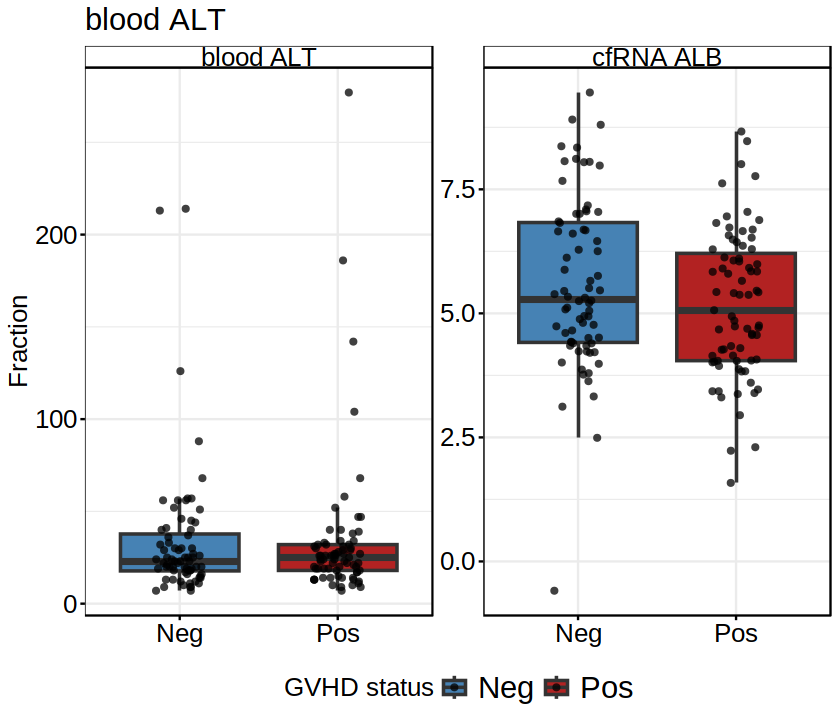

In [7]:
VAR = "blood_ALT"

options(repr.plot.width=7, repr.plot.height=6)

plot_df %>% 
    ggplot(aes(x=expGroup, y=value, fill =  expGroup)) +
    geom_boxplot(outlier.shape=NA,size= 0.75)+
    geom_point(position =  position_jitterdodge(jitter.height=0, 
                                                jitter.width=.3, 
                                                seed=42),
                size = 2, alpha = 0.75, stroke=NA)+
    theme_cfrna_slides()+
    labs(title = gsub("_"," ",VAR), y = "Fraction", x = "Timepoint", fill = "GVHD status")+
    theme(axis.title.x = element_blank(), 
        legend.position = "bottom",
        legend.text = element_text(size = 18))+
    # coord_cartesian(ylim = c(0,0.001))+
    facet_wrap(~measurement, scales = "free")+
    scale_fill_manual(values = c("Neg" = "#4682B4", "Pos" = "#B22222")) 

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


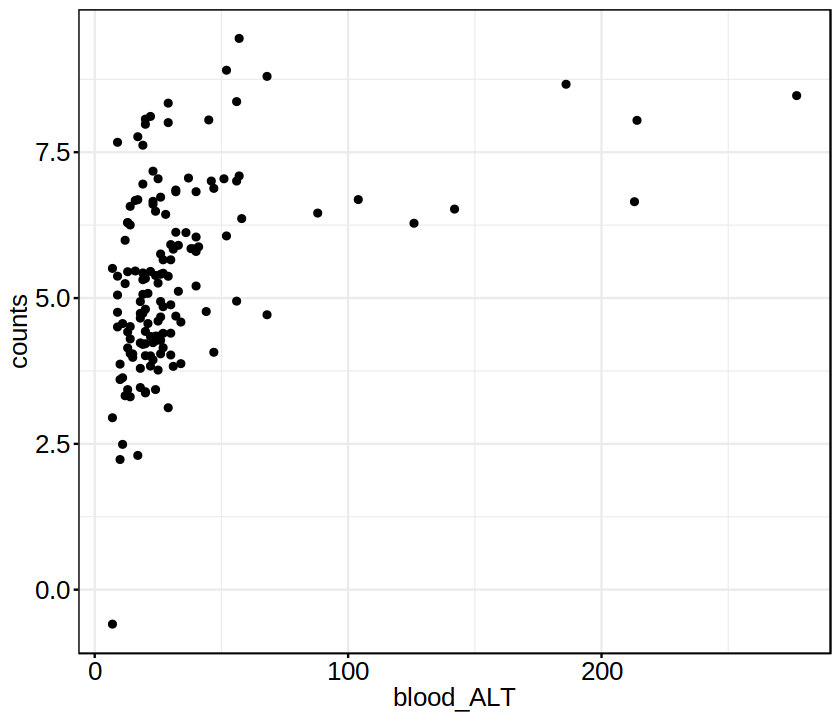

In [10]:
cnt_df %>% 
    ggplot(aes(x=blood_ALT, y=counts))+
    geom_point() + theme_cfrna_slides()

---
---
# ARCHIVE

## longitudinal

In [ ]:
##------------------------------------
## Run DESeq
subset_mdf = mdf_cgvhd_daa %>% filter(!is.na(rel_cgvhd)) %>% mutate(rel_cgvhd= as.numeric(rel_cgvhd))
subset_cnts = counts_daa[,subset_mdf$sample_id]
dds_long <- DESeqDataSetFromMatrix(subset_cnts,
                                colData = subset_mdf,
                                design = ~ timepoint + rel_cgvhd )

# Normalize counts and estimate size factors
dds_long <- estimateSizeFactors(dds_long)

# Compute baseMean and filter genes
baseMean_values <- rowMeans(counts(dds_long, normalized=TRUE))
dds_long <- dds_long[baseMean_values > 5, ]

dds_long <- DESeq(dds_long)


res_long <- results(dds_long) 

res_long_df <- res_long %>% data.frame()
res_long_df <- merge(res_long_df,gene_key, by.x=0, by.y="gene_id") %>% column_to_rownames(.,"Row.names")

  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

factor levels were dropped which had no samples



using pre-existing size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



In [ ]:
res_long_df %>% filter(padj < 0.1) %>% nrow


[1] 34

In [ ]:
res_long_df %>% 
    arrange(padj) %>% 
    filter(log2FoldChange > 0) %>%
    head

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_name,gene_type
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
ENSG00000000460.17,50.12910,0.0023499887,0.0005605466,4.192316,2.761208e-05,0.03118938,C1orf112,protein_coding
ENSG00000198087.7,235.11044,0.0008757118,0.0002071832,4.226751,2.370893e-05,0.03118938,CD2AP,protein_coding
ENSG00000223361.5,13.10121,0.0031348960,0.0007418928,4.225538,2.383707e-05,0.03118938,FTH1P10,transcribed_processed_pseudogene
ENSG00000229344.1,17.91760,0.0042159804,0.0010436953,4.039474,5.357113e-05,0.04950946,MTCO2P12,unprocessed_pseudogene
ENSG00000240409.1,13.57890,0.0068271811,0.0017003368,4.015193,5.939706e-05,0.05031921,MTATP8P1,unprocessed_pseudogene
ENSG00000256618.3,1142.85629,0.0063620665,0.0016279564,3.908008,9.306026e-05,0.06757504,MTRNR2L1,protein_coding


In [ ]:
GENEs = c("C1orf112","CD2AP","FTH1P10","MTCO2P12")



GENEIDS = gene_key %>% filter(gene_name %in% GENEs) %>% pull(gene_id)

### Normalize counts
CNTS = edgeR::cpm(counts_daa)

### Combine counts with metadata
cnt_df = merge(mdf_cgvhd_daa %>% select(sample_id, date_cgvhd, rel_cgvhd, timepoint, Record_ID), 
        data.frame(t(CNTS[GENEIDS,])),
        by.x="sample_id",by.y=0) %>% 
    reshape2::melt(id.vars = c("sample_id","date_cgvhd","rel_cgvhd","timepoint", "Record_ID"), variable.name = "gene_id",value.name = "counts")
cnt_df = merge(cnt_df, gene_key, by.x="gene_id", by.y="gene_id") %>% 
    mutate(gene_name = factor(gene_name, levels = GENEs)) 

Don't know how to automatically pick scale for object of type <difftime>.
Defaulting to continuous.
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 244 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 244 rows containing missing values or values outside the scale range
(`geom_point()`).”
Don't know how to automatically pick scale for object of type <difftime>.
Defaulting to continuous.
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 244 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 244 rows containing missing values or values outside the scale range
(`geom_point()`).”


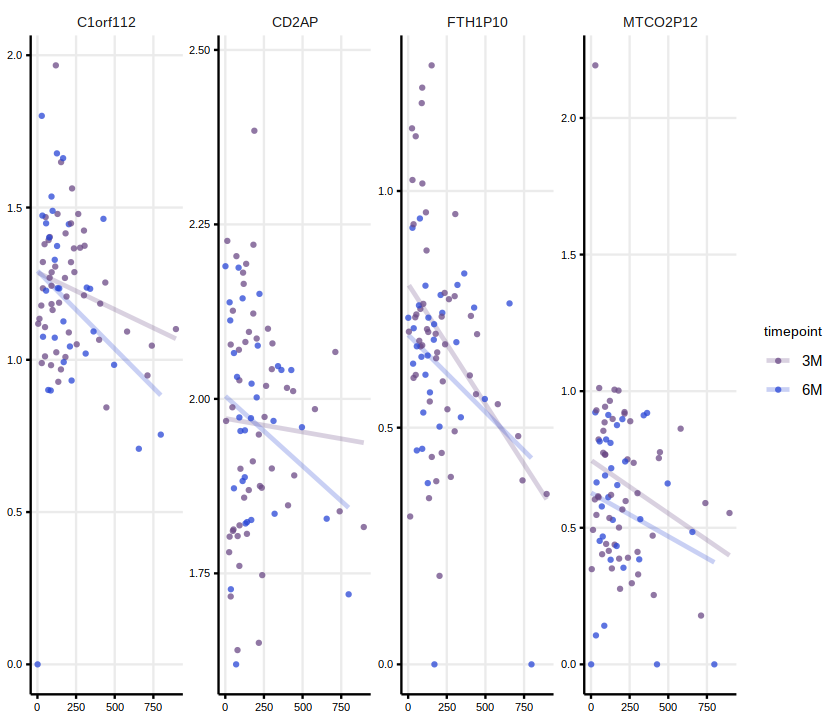

In [ ]:
COLS = c("3M" = "#6B4A86", "6M" = "#2846D5")
cnt_df %>% 
    ggplot(aes(x=-rel_cgvhd, y=log10(counts+1), color = timepoint))+
    geom_line(stat="smooth",method = "lm",
            # color = "black",
            size = 1,alpha = 0.25)+
    geom_point(size = 1.5, alpha = 0.75, stroke=NA)+
    facet_wrap(~gene_name, nrow=1, scales = "free")+
        theme_cfrna_print()+
    labs(y = "log10(CPM+1)", x= "days to aGVHD onset")+
    theme(
        legend.position = "right",
        strip.text = element_text(size=8),
        strip.background = element_blank()
        )+
    scale_color_manual(values = COLS )+
    theme(
      axis.title = element_blank(),
      panel.border = element_blank(),             # Remove all borders initially
      axis.line = element_line(),                 # Add back the bottom and left lines
      axis.line.x.top = element_blank(),          # Ensure top border is removed
      axis.line.y.right = element_blank(),        # Ensure right border is removed
      panel.grid.minor.y = element_blank(),       # Remove minor gridlines
      panel.grid.minor.x = element_blank()        # Remove major x gridlines
    )+
    guides(color = guide_legend(title.hjust = 0                                           # Fine-tune title horizontal alignment))
    ))

### Save
WIDTH = 6.8
HEIGHT=2

ggsave("figures/aGVHD_corGenes.pdf", width=WIDTH, height=HEIGHT, units="in")

In [44]:
table(cnt_df$expGroup)


Neg Pos 
390 402 

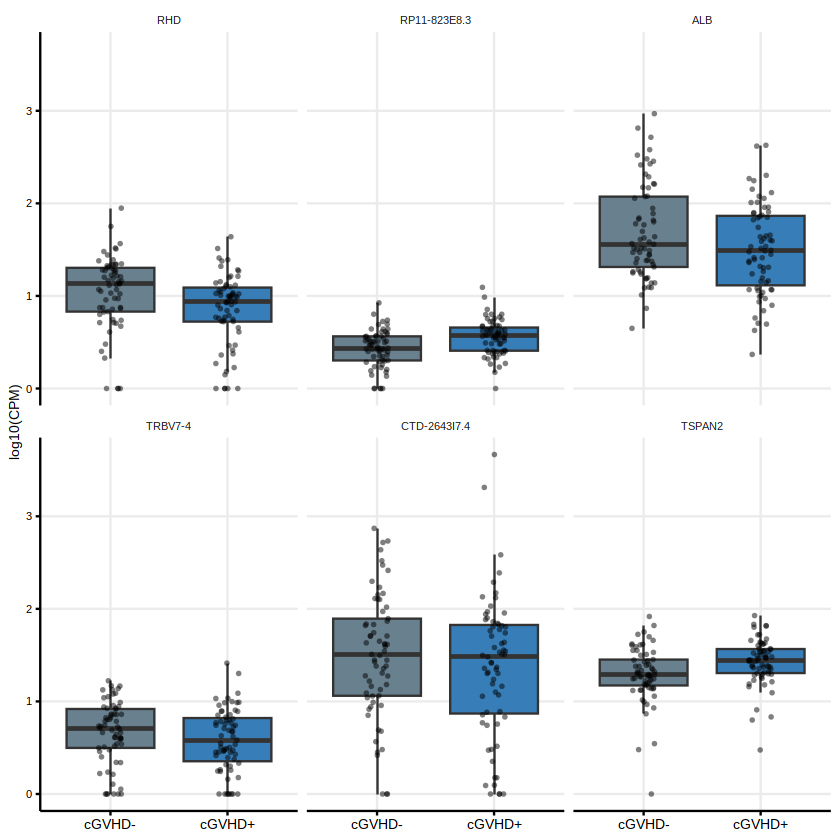

In [45]:
GENEs = c("RHD","RP11-823E8.3","ALB","TRBV7-4","CTD-2643I7.4","TSPAN2")




GENEIDS = gene_key %>% filter(gene_name %in% GENEs) %>% pull(gene_id)

### Normalize counts
CNTS = cpm_values
CNTS = edgeR::cpm(counts)

### Combine counts with metadata
cnt_df = merge(mdf_cgvhd_daa %>% select(sample_id, date_cgvhd, expGroup, timepoint), 
        data.frame(t(CNTS[GENEIDS,])),
        by.x="sample_id",by.y=0) %>% 
    reshape2::melt(id.vars = c("sample_id","date_cgvhd", "expGroup","timepoint"), variable.name = "gene_id",value.name = "counts")

### Add gene names for plotting
cnt_df = merge(cnt_df, gene_key, by.x="gene_id", by.y="gene_id") %>% 
    mutate(gene_name = factor(gene_name, levels = GENEs))

### Make plot
cnt_df %>% 
    mutate(expGroup =ifelse(expGroup == "Pos","cGVHD+","cGVHD-")) %>%
    ggplot(aes(x=expGroup, y=log10(counts+1), fill = expGroup))+
    geom_boxplot(outlier.shape = NA) +
    geom_point(position =  position_jitterdodge(jitter.height=0, 
                                                jitter.width=.2, 
                                                seed=42),
                size = 1.3, alpha = 0.5, stroke=NA)+
    theme_cfrna_print()+
    labs(y = "log10(CPM)")+
    theme(
        axis.text.x = element_text(size = 8),
        axis.title.x = element_blank(),
        panel.border = element_blank(),                  # Remove all borders initially
        axis.line = element_line(),                      # Add back the bottom and left lines
        axis.line.x.top = element_blank(),               # Ensure top border is removed
        axis.line.y.right = element_blank(),             # Ensure right border is removed
        panel.grid.minor.y = element_blank()             # Remove minor gridlines
        )+
    scale_fill_manual(values = COLORs)+
    facet_wrap(~gene_name)+
    theme(strip.text = element_text(size = 6, vjust = 1),
        strip.background = element_blank())

# ### Save
# WIDTH = 2.5
# HEIGHT= 1.7

# ggsave("figures/aGVHD_EGenes.pdf", width=WIDTH, height=HEIGHT, units="in")

---
## ARCHIVE

### train

In [45]:
## train a model
set.seed(42)

## prep counts
counts_vst_train_sub = counts_vst_train[top_genes,training$sample_id] %>% t() %>% data.frame()
counts_vst_train_sub$y = factor(training$expGroup)

## parameters
metric <- "Accuracy"
control <- trainControl(method="cv",number=5)
tunegrid <- expand.grid(alpha = c(0.25,0.5,0.75),
                        lambda = seq(0.00001, 1, length=10000))

## fit model
glmnet_fit <- train(y~., 
                data=counts_vst_train_sub, 
                metric = metric,
                method='glmnet',
                preProcess = c("center","scale"),
                trControl=control,
                tuneGrid = tunegrid)

glmnet_fit %>% saveRDS("./outputs/cGVHD-model.rds")

# ### get outputs
glmnet_fit = readRDS("./outputs/cGVHD-model.rds")

counts_vst_test_sub = counts_vst_test[top_genes,test$sample_id] %>% t() %>% data.frame()

training$prob = predict(glmnet_fit, counts_vst_train_sub, type = "prob")$Pos
test$prob = predict(glmnet_fit, counts_vst_test_sub, type = "prob")$Pos

all_df = rbind(training %>% mutate(Grp = "train"),test %>% mutate(Grp = "test")) %>% 
    mutate(Grp = factor(Grp, levels = c("train","test")))


### class scores

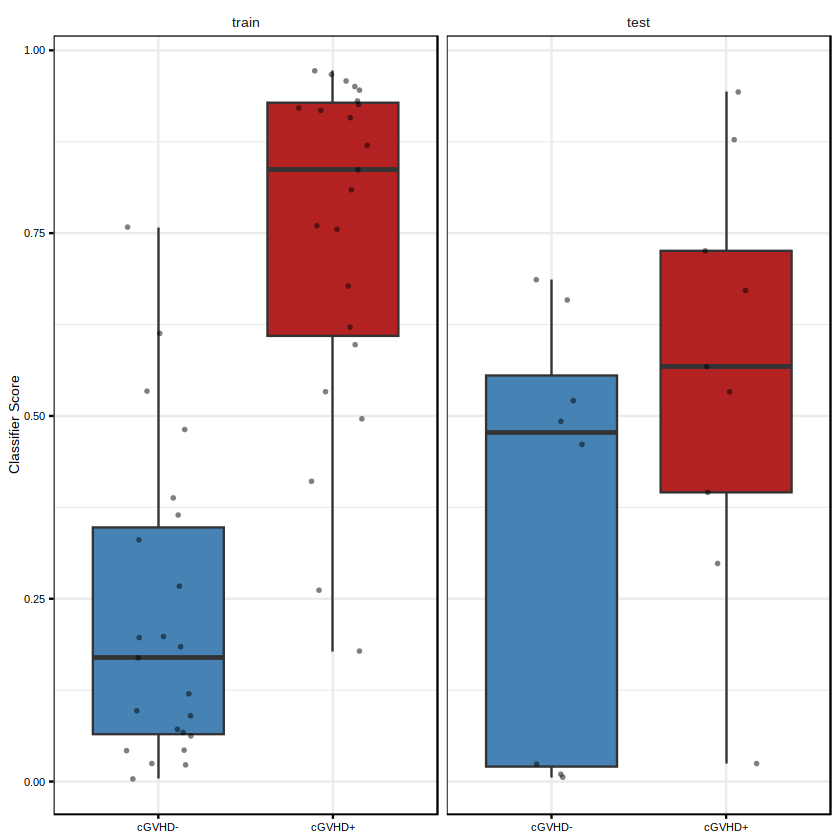

In [46]:
## plot probs
all_df %>% 
    filter(ORIGIN == "MCC") %>% 
    mutate(expGroup2 = ifelse(expGroup == "Pos","cGVHD+","cGVHD-")) %>%
    ggplot(aes(x=expGroup2, y=prob, fill = expGroup2))+
    geom_boxplot(outlier.shape = NA) +
    geom_jitter(width = 0.2, height = 0, size = 1.3, alpha = 0.5, stroke=NA)+
    theme_cfrna_print()+
    facet_wrap(~Grp)+
    scale_fill_manual(values = COLORs)+
    labs(y = "Classifier Score")+
    theme(
        axis.title.x = element_blank(),
        strip.text = element_text(size = 8),
        strip.background = element_blank()
    )

ggsave("./figures/cGVHD_SCORES.pdf", width = 2.75, height = 2)


### ROC

Area under the curve: 95.23%
Area under the curve: 62.27%


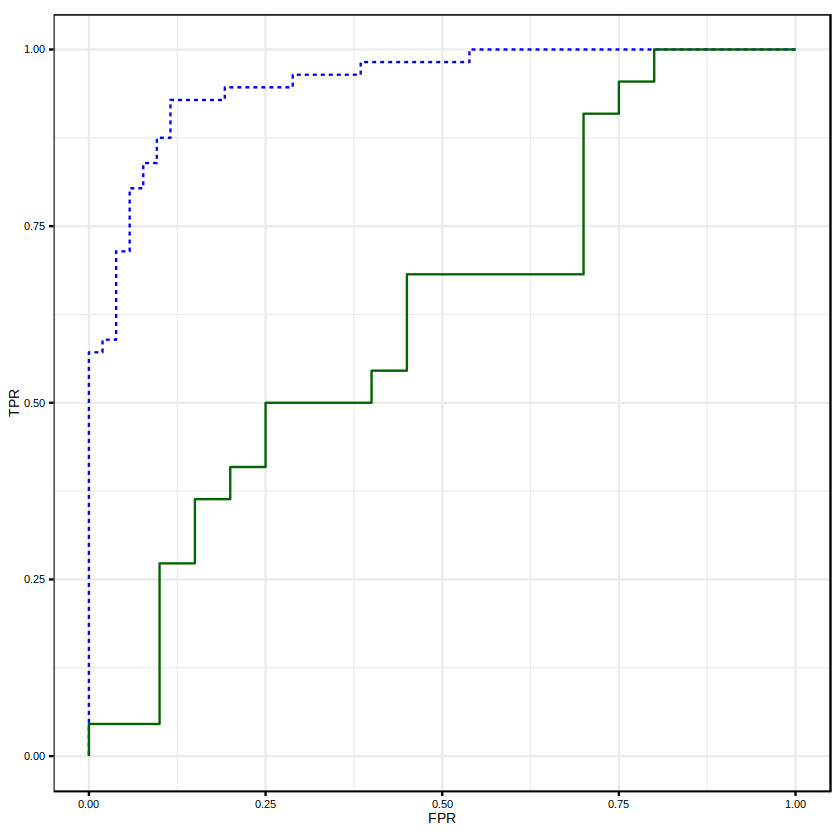

In [47]:
suppressMessages(library(pROC))
##------------------------------------
## ROC plot
##------------------------------------

train_mdf = all_df %>% filter(Grp == "train")
roc_train <- suppressMessages(roc(response = train_mdf$expGroup, predictor = train_mdf$prob,
                percent=TRUE,
                ci=TRUE, 
                boot.n=10000, boot.stratified=TRUE,
                print.auc=TRUE,
                print.thres="best",
                print.thres.best.method="youden"))

test_mdf = all_df %>% filter(Grp == "test")
roc_test <- suppressMessages(roc(response = test_mdf$expGroup, predictor = test_mdf$prob,
                percent=TRUE,
                ci=TRUE, 
                boot.n=10000, boot.stratified=TRUE,
                print.auc=TRUE,
                print.thres="best",
                print.thres.best.method="youden"))

##------------------------------------
## get roc values
##------------------------------------

train_roc <- data.frame("sensitivity" = roc_train$sensitivities,
                        "specificity" = roc_train$specificities,
                       "set" = "train")

test_roc <- data.frame("sensitivity" = roc_test$sensitivities,
                        "specificity" = roc_test$specificities,
                       "set" = "test")


all_roc <- do.call("rbind",list(train_roc, test_roc)) %>%
    mutate(FPR = 1-(as.numeric(specificity)/100),
          TPR = as.numeric(sensitivity)/100)


## malke plot

all_roc %>% 
    mutate(set = factor(set,levels = c("train","validate","test"))) %>% 
    ggplot(aes(x= FPR, y= TPR, group = set, linetype = set, color = set))+
    geom_path()+
    theme_cfrna_slides()+
    theme(aspect.ratio = 1,
        axis.title.x = element_text(size = 8),
        axis.text.x = element_text(size = 6),
        axis.title.y = element_text(size = 8), 
        axis.text.y = element_text(size = 6)
        ) +
    scale_linetype_manual(values = c("train"="dashed","test"="solid"))+
    scale_color_manual(values = c("train"="blue","test"="dark green"))

WIDTH = 2.3
HEIGHT = 1.9
ggsave("./figures/cGVHD_ROC.pdf", width = WIDTH, height = HEIGHT)

print(roc_train$auc)
print(roc_test$auc)

---
## Cluster

In [14]:
library(DESeq2)

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:lubridate’:

    intersect, setdiff, union


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, append, as.data.frame, basename, cbind, colnames,
    dirname, do.call, duplicated, eval, evalq, Filter, Find, get, grep,
    grepl, intersect, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, setdiff, sort, table, tapply,
    union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following objects are masked from ‘package:lubridate’:

    second, second<-


The follow

### Select samples

In [12]:
TIME = c("HD", "3M","6M","taper_start","taper_end","cGVHD")
mdf_cgvhd <- mdf %>% 
    filter(timepoint %in% TIME) %>% 
    ## DFCI filters
    filter(rel_drug <= 0 | ORIGIN == "MCC" | timepoint == "HD") %>% 
    filter(PredEqui_01 == 0 | ORIGIN == "MCC" | timepoint == "HD") %>% 
    ## remove samples with cGVHD
    filter(rel_cgvhd < 0 | is.na(rel_cgvhd) | ORIGIN == "MCC") %>% 
    mutate(expGroup = ifelse(timepoint %in% c("3M","6M"),"3-6M",as.character(timepoint))) %>% 
    mutate(expGroup = factor(expGroup, levels = c("HD","3-6M","taper_start","taper_end","cGVHD")))

table(mdf_cgvhd$expGroup, !is.na(mdf_cgvhd$date_cgvhd))

### get counts
counts = read.delim("../1_DATA/counts_sQC_gAll_nRaw.tsv")
counts_daa = counts[,mdf_cgvhd$sample_id]

### get norm counts
counts_vst = read.delim("../1_DATA/counts_sQC_gAll_nVST.tsv")
counts_vst = counts_vst[,mdf_cgvhd$sample_id]

             
              FALSE TRUE
  HD             18    0
  3-6M           41   46
  taper_start    38   12
  taper_end      16    7
  cGVHD           0   12

In [26]:
counts_no_plat = read.delim("../1_DATA/counts_sQC_gAll_nPlatRegressed.tsv")
# counts_no_plat %>% head

In [32]:
counts_no_plat = counts_no_plat[,mdf_cgvhd$sample_id]

counts_no_plat %>% head

,gvhd_hct_cfrna_102_bp61x61,gvhd_hct_cfrna_103_bp61x61,gvhd_hct_cfrna_143_bp61x61,gvhd_hct_cfrna_144_bp61x61,gvhd_hct_cfrna_146_bp61x61,gvhd_hct_cfrna_155_bp61x61,gvhd_hct_cfrna_156_bp61x61,gvhd_hct_cfrna_18_bp51x51,gvhd_hct_cfrna_181_bp61x61,gvhd_hct_cfrna_19_bp51x51,⋯,moffitt_cfrna_75_bp61x61,moffitt_cfrna_76_bp61x61,moffitt_cfrna_79_bp61x61,moffitt_cfrna_80_bp61x61,moffitt_cfrna_82_bp61x61,moffitt_cfrna_83_bp61x61,moffitt_cfRNA_90_bp61x61,moffitt_cfRNA_95_bp61x61,moffitt_cfRNA_98_bp61x61,moffitt_cfRNA_99_bp61x61
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSG00000223972.5,-11.572718076,-7.730655003,-10.47780373,-10.317371992,-0.569997993,-8.596327221,-11.234185227,-7.454241566,-3.537238528,-3.096313555,⋯,-2.227617183,-4.076769535,-2.592918945,-1.833813996,-3.452831569,-1.836973313,-2.948105346,-5.111999150,-2.058488027,-5.545237232
ENSG00000227232.5,-0.261293263,-0.160662799,1.69911418,-0.255986518,2.780328386,-0.199436243,0.766524875,-0.175700780,-0.094295430,-0.105914440,⋯,0.953704413,-0.084725706,-0.053887493,-0.038111349,-0.071758678,-0.038177007,-0.061269175,-0.127022987,0.957219350,-0.156809343
ENSG00000278267.1,0.041541880,0.025543080,0.04783653,0.040698184,0.034924635,0.031707502,0.037119195,0.027933903,0.014991621,0.016838877,⋯,0.007360334,0.013470172,0.008567338,0.006059158,0.011408600,0.006069597,0.009740920,0.020194833,0.006801510,0.024930436
ENSG00000243485.5,0.009754121,0.005997569,0.01123212,0.009556019,0.008200378,0.007444988,0.008715665,0.006558939,1.003520064,0.003953804,⋯,0.001728222,0.003162825,0.002011629,0.001422703,0.002678763,0.001425154,0.002287188,0.004741789,0.001597009,0.005853719
ENSG00000284332.1,0.000000000,0.000000000,0.00000000,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000,⋯,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000
ENSG00000237613.2,-0.009650706,-0.005933981,-0.01111303,-0.009454704,-0.008113436,-0.007366055,-0.008623260,-0.006489400,-0.003482744,-0.003911885,⋯,-0.001709899,-0.003129292,-0.001990301,-0.001407619,-0.002650363,-0.001410044,-0.002262939,-0.004691516,-0.001580077,-0.005791656


### cluster

In [33]:
### select top 500 most variable genes 
# top_genes = counts_vst %>% 
top_genes = counts_no_plat %>%
    apply(1, sd) %>% 
    sort(decreasing = TRUE) %>% 
    names %>% 
    head(500)


### PCA of those genes
pca = prcomp(t(counts_vst[top_genes,]), scale = TRUE)

pca_df = merge(mdf_cgvhd, pca$x, by.x="sample_id",by.y=0)

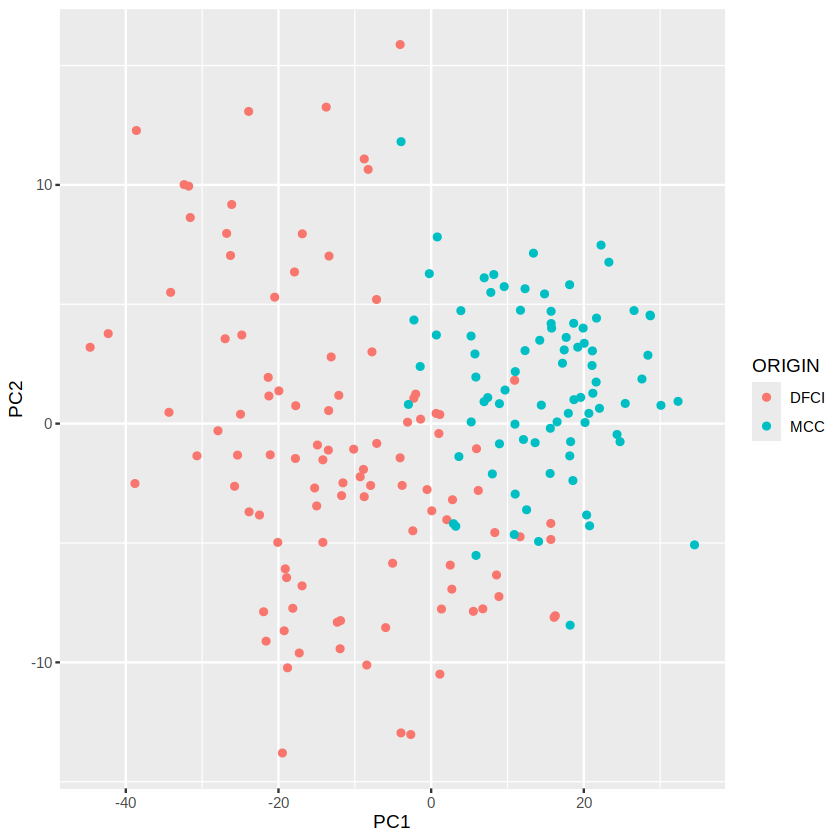

In [37]:
pca_df %>% 
    ggplot(aes(x=PC1, y=PC2, color = ORIGIN))+
    geom_point()

---
---
# ARCHIVE

## Correlation

In [56]:
EXP = "3-6M"
EXP = "taper_start"
### run wilcoxon tests
all_metrics = c(colnames(metrics),colnames(decon))
all_metrics = all_metrics[!all_metrics %in% c("sample_id","Record_ID","timepoint")]

all_res_corr = lapply(all_metrics, function(X) {

    scores= mdf_cghvd %>% 
        filter(expGroup == EXP) %>% 
        filter(!is.na(date_cgvhd)) %>% pull(X) %>% as.numeric()
    times= mdf_cghvd %>% 
        filter(expGroup == EXP) %>% 
        filter(!is.na(date_cgvhd)) %>% pull(rel_cgvhd) %>% as.numeric()

    res = cor.test(scores,times, method = "spearman")
    return(c(X=X, p=res$p.value, cor=res$estimate)) }
    ) 
    
all_res_corr = all_res_corr %>%  do.call(rbind, .) %>% as.data.frame()

all_res_corr %>% filter(cor.rho >0) %>% arrange(p) %>% head(10)

Warning message in cor.test.default(scores, times, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(scores, times, method = "spearman"):
“Cannot compute exact p-value with ties”


,X,p,cor.rho
,<chr>,<chr>,<chr>
1,plasma_cell,0.0554813240816213,0.573426573426573
2,melanocyte,0.0666290014487934,0.552447552447553
3,leukocyte_activity,0.0793029394097802,0.531468531468532
4,nk_cell,0.121319356446693,0.475524475524476
5,thymocyte,0.133836315738433,0.461538461538462
6,macrophage,0.147205377767155,0.447552447552448
7,pancreatic_delta_cell,0.147205377767155,0.447552447552448
8,intrahepatic_cholangiocyte,0.176577010697551,0.41958041958042
9,basal_cell_of_prostate_epithelium,0.246255228012161,0.363636363636364


Warning message in geom_point(outlier.shape = NA):
“Ignoring unknown parameters: `outlier.shape`”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”


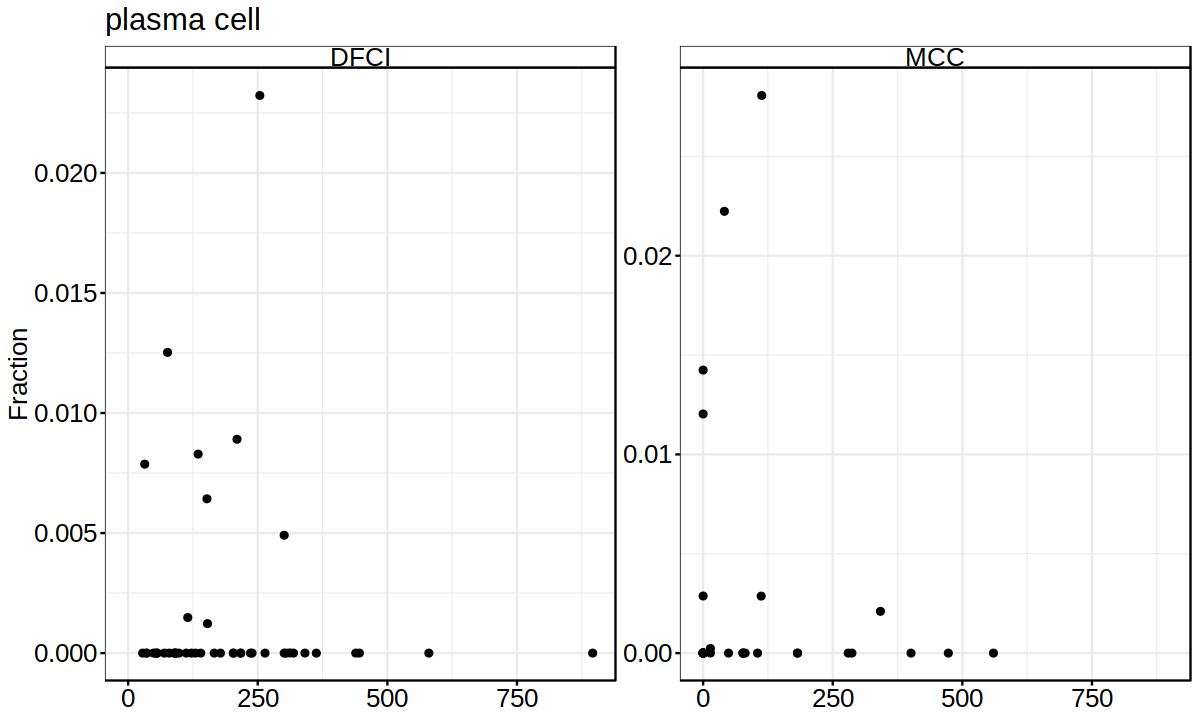

In [59]:
VAR = "plasma_cell"

options(repr.plot.width=10, repr.plot.height=6)

mdf_cghvd %>% 
    filter(!is.na(date_cgvhd)) %>%
    ggplot(aes(x=-as.numeric(rel_cgvhd), y=!!sym(VAR))) +
    geom_point(outlier.shape = NA) +
  
    theme_cfrna_slides()+
    labs(title = gsub("_"," ",VAR), y = "Fraction", x = "Timepoint", fill = "GVHD status")+
    theme(axis.title.x = element_blank(), 
        legend.position = "bottom",
        legend.text = element_text(size = 18))+
    ggh4x::facet_grid2(.~ORIGIN, scales = "free_y", independent = "y")+
    scale_fill_manual(values = c("FALSE" = "#4682B4", "TRUE" = "#B22222"))

---
---
# ARCHIVE

---
## DFCI

In [602]:
TIME = c("3M","6M")

### load data and merge
metrics = read.delim("../1_DATA/metrics_passQC.tsv") %>% unique()
decon = read.delim("../1_DATA/decon_passQC.new.tsv")

# ### Scale decon
# qbits = metrics %>% remove_rownames() %>% select(sample_id, SCALE_qubit) %>% column_to_rownames(.,"sample_id")
# decon = decon %>% remove_rownames() %>% column_to_rownames(.,"sample_id")
# decon = decon[rownames(qbits),]
# decon = decon * qbits$SCALE_qubit
# decon = decon %>% rownames_to_column("sample_id")


mdf_Nm = mdf %>% 
    filter(timepoint %in% TIME) %>% 
    filter(rel_drug <= 0) %>% 
    filter(PredEqui_01 == 0) %>% 
    filter(rel_cgvhd < 0 | is.na(rel_cgvhd))


mdf_Nm <- merge(mdf_Nm, metrics, by="sample_id")
mdf_Nm <- merge(mdf_Nm, decon, by="sample_id")

print(table(is.na(mdf_Nm$cGVHD_date)))


FALSE  TRUE 
   47    44 


In [603]:
### run wilcoxon tests
all_metrics = c(colnames(metrics),colnames(decon))
all_metrics = all_metrics[!all_metrics %in% c("sample_id","Record_ID","timepoint")]

all_res_wilcox = lapply(all_metrics, function(X) {
    g1= mdf_Nm %>% filter(is.na(cGVHD_date)) %>% pull(X) %>% as.numeric()
    g2= mdf_Nm %>% filter(!is.na(cGVHD_date)) %>% pull(X) %>% as.numeric()
    FC= median(g2) / median(g1)
    res = wilcox.test(g1,g2)
    return(c(X=X, p=res$p.value, fc = FC)) }
    )  %>% do.call(rbind, .) %>% as.data.frame()

all_res_wilcox$fc = as.numeric(all_res_wilcox$fc)

all_res_wilcox %>% arrange(p) %>% head(5)

Warning message in wilcox.test.default(g1, g2):
“cannot compute exact p-value with ties”


Warning message in wilcox.test.default(g1, g2):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(g1, g2):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(g1, g2):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(g1, g2):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(g1, g2):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(g1, g2):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(g1, g2):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(g1, g2):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(g1, g2):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(g1, g2):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(g1, g2):
“cannot compute exact p-value with ties”
Warning message in wi

,X,p,fc
,<chr>,<chr>,<dbl>
1,hepatocyte,0.00257846142056196,0.04081979
2,podocyte,0.00887375786750429,0.30795159
3,immature_B_cell,0.0124984218816369,1.14625499
4,classical_monocyte,0.0166428347711124,2.77593317
5,fibroblast,0.0286686318844558,0.10884109


In [604]:
all_res_wilcox %>% filter(fc > 1) %>% arrange(p) %>% head(10)

,X,p,fc
,<chr>,<chr>,<dbl>
1,immature_B_cell,0.0124984218816369,1.146255
2,classical_monocyte,0.0166428347711124,2.775933
3,erythroblast,0.0424405830116054,10.500621
4,CD8_positive_T_cell,0.0440841365237332,1.580154
5,kidney_proximal_tubule_epithelial_cell,0.0449258605594942,1.060273
6,colon_endothelial_cell,0.0745907402743636,77091.616792
7,endothelial_cell_of_hepatic_sinusoid,0.0812877056483989,1.485803
8,vascular_endothelial_cell,0.0930104233681494,5.627412
9,kidney_connecting_tubule_epithelial_cell,0.0977418306576009,1.077155


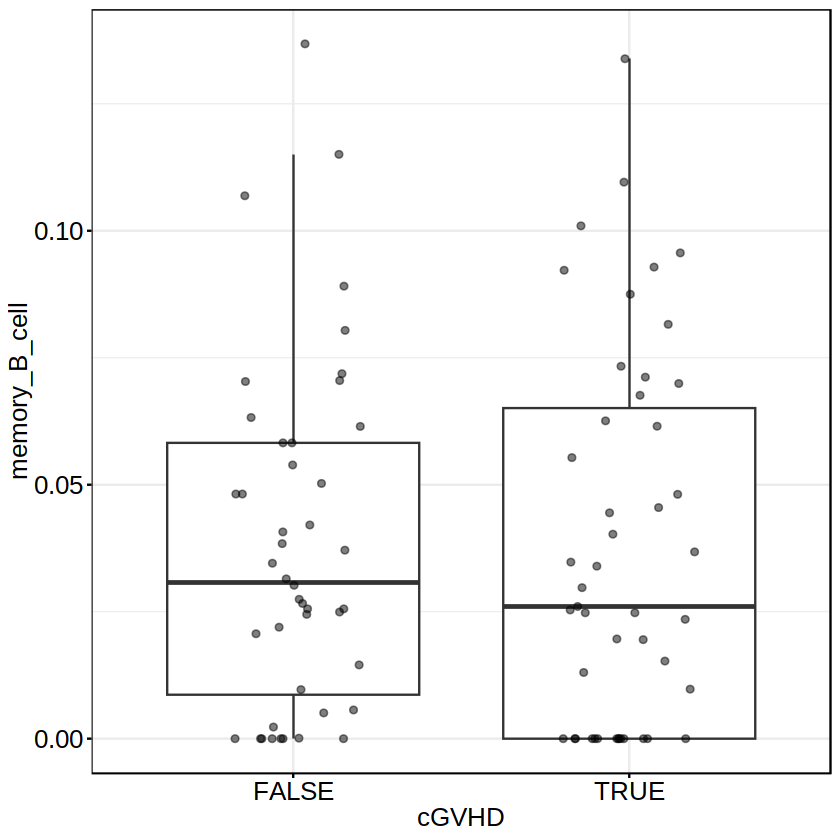

In [605]:
VAR = "classical_monocyte"
VAR = "vascular_endothelial_cell"


mdf_Nm %>% 
    ggplot(aes(x=cGVHD, y=!!sym(VAR))) +
    geom_boxplot(outlier.shape = NA) +
    geom_jitter(width = 0.2, alpha = 0.5, height = 0) +
    theme_cfrna_slides()

In [568]:
### run corr tests
all_metrics = c(colnames(metrics),colnames(decon))
all_metrics = all_metrics[!all_metrics %in% c("sample_id","Record_ID","timepoint")]

all_res_corr = lapply(all_metrics, function(X) {
    scores= mdf_Nm %>% filter(!is.na(cGVHD_date)) %>% pull(X) %>% as.numeric()
    times = mdf_Nm %>% filter(!is.na(cGVHD_date)) %>% pull(rel_cgvhd) %>% as.numeric()
    res = cor.test(scores,times)
    return(c(X=X, p=res$p.value, cor=res$estimate)) }
    )  %>% do.call(rbind, .) %>% as.data.frame()

all_res_corr %>% arrange(p) %>% head(5)

,X,p,cor.cor
,<chr>,<chr>,<chr>
1,kidney_loop_of_Henle_epithelial_cell,0.000119282786649434,-0.531889923202652
2,pancreatic_endocrine_epithelial_cell,0.000119932863112966,-0.531734726944147
3,respiratory_secretory_epithelial_cell,0.000153778407933656,-0.524554857684123
4,choroid_plexus_epithelial_cell,0.000425092252441532,-0.493399849076849
5,perineurial_cell,0.000483508882824532,-0.489232964956873


In [569]:
all_res_corr %>% filter(cor.cor >0) %>% arrange(p) %>% head(15)

,X,p,cor.cor
,<chr>,<chr>,<chr>
1,leukocyte_activity,0.0604196711179855,0.275979071224318
2,peripheral_neuron,0.0722453434559366,0.264631793392187
3,monocyte_activity,0.115648953902422,0.23259286283
4,non_classical_monocyte,0.139927969612377,0.218578063640641
5,platelet_CBC,0.154501168577576,0.211019469430592
6,SCALE_qubit,0.154966409782511,0.210786986681592
7,lymphocyte_activity,0.171649659328832,0.202767893355192
8,lymphocyte_CBC,0.209143320784181,0.186606118843849
9,dendritic_cell,0.271781525545272,0.163623810553732


Warning message:
“Removed 44 rows containing missing values or values outside the scale range
(`geom_point()`).”


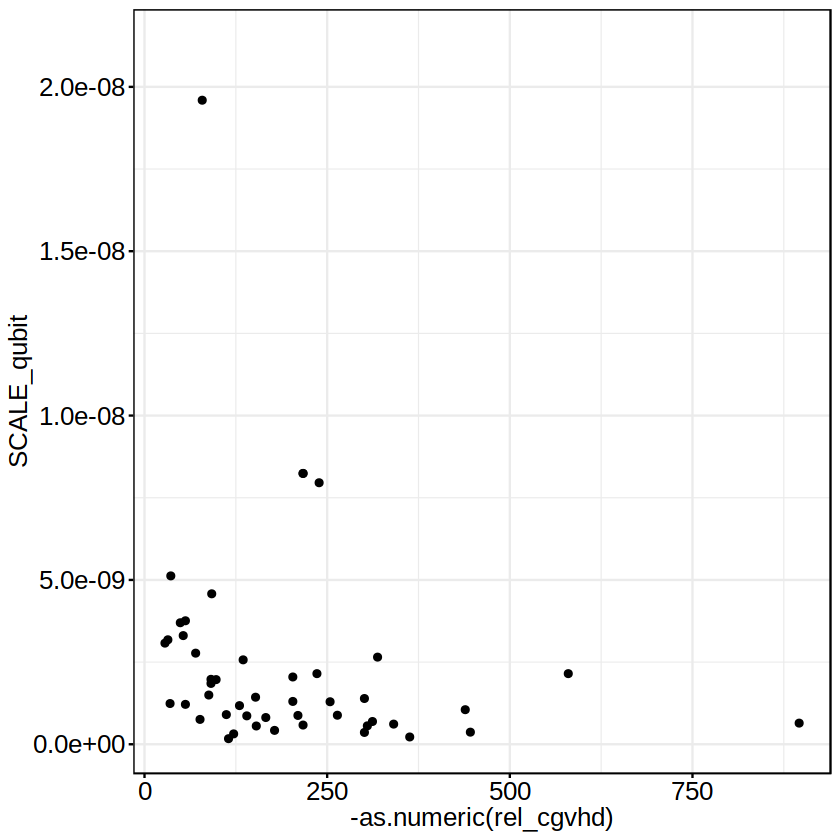

In [576]:
# VAR = "leukocyte_activity"
# VAR = "peripheral_neuron"
# VAR = "monocyte_activity"
# VAR = "non_classical_monocyte"
# CAR = "CD8_positive_T_cell"
VAR = "SCALE_qubit"


mdf_Nm %>% 
    ggplot(aes(x=-as.numeric(rel_cgvhd), y=!!sym(VAR))) +
    geom_point()+
    theme_cfrna_slides()

---
## MCC

In [61]:
TIME = c("taper_start")

### load data and merge
metrics = read.delim("../1_DATA/metrics_passQC.tsv") %>% unique()
decon = read.delim("../1_DATA/decon_passQC.new.tsv")

# ### Scale decon
# qbits = metrics %>% remove_rownames() %>% select(sample_id, SCALE_qubit) %>% column_to_rownames(.,"sample_id")
# decon = decon %>% remove_rownames() %>% column_to_rownames(.,"sample_id")
# decon = decon[rownames(qbits),]
# decon = decon * qbits$SCALE_qubit
# decon = decon %>% rownames_to_column("sample_id")


mdf_Nm = read.delim("../1_DATA/sample_meta_passQC.tsv") %>% 
    filter(timepoint %in% TIME) %>% 
    select(!SCALE_qubit) %>% 
    mutate(rel_cgvhd = ymd(date) - ymd(date_cgvhd))

mdf_Nm <- merge(mdf_Nm, metrics, by="sample_id")
mdf_Nm <- merge(mdf_Nm, decon, by="sample_id") %>% unique()
 
print(table(is.na(mdf_Nm$date_cgvhd)))


FALSE  TRUE 
   11    29 


In [62]:
### run wilcoxon tests
all_metrics = c(colnames(metrics),colnames(decon))
all_metrics = all_metrics[!all_metrics %in% c("sample_id","Record_ID","timepoint")]

all_res_wilcox = lapply(all_metrics, function(X) {
    g1= mdf_Nm %>% filter(is.na(date_cgvhd)) %>% pull(X) %>% as.numeric()
    g2= mdf_Nm %>% filter(!is.na(date_cgvhd)) %>% pull(X) %>% as.numeric()
    FC= median(g2) / median(g1)
    res = wilcox.test(g1,g2)
    return(c(X=X, p=res$p.value, fc = FC)) }
    )  %>% do.call(rbind, .) %>% as.data.frame()

all_res_wilcox$fc = as.numeric(all_res_wilcox$fc)

all_res_wilcox %>% arrange(p) %>% head(5)

Warning message in wilcox.test.default(g1, g2):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(g1, g2):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(g1, g2):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(g1, g2):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(g1, g2):
“cannot compute exact p-value with ties”


Warning message in wilcox.test.default(g1, g2):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(g1, g2):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(g1, g2):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(g1, g2):
“cannot compute exact p-value with ties”


,X,p,fc
,<chr>,<chr>,<dbl>
1,leukocyte_activity,0.00210722768647467,2.150571e+00
2,lymphocyte_activity,0.00297937006216243,1.871990e+00
3,SCALE_qubit,0.00346510021722201,2.131579e+00
4,podocyte,0.00633218309613995,1.793159e+14
5,tendon_cell,0.00701131927662438,5.999076e+00


In [63]:
all_res_wilcox %>% filter(fc > 1) %>% arrange(p) %>% head(10)

,X,p,fc
,<chr>,<chr>,<dbl>
1,leukocyte_activity,0.00210722768647467,2.150571e+00
2,lymphocyte_activity,0.00297937006216243,1.871990e+00
3,SCALE_qubit,0.00346510021722201,2.131579e+00
4,podocyte,0.00633218309613995,1.793159e+14
5,tendon_cell,0.00701131927662438,5.999076e+00
6,dendritic_cell,0.00943953473789687,1.709231e+00
7,pulmonary_alveolar_type_1_cell,0.0214811268566387,2.278930e+12
8,fibroblast,0.0276458189246564,3.992231e+13
9,monocyte_activity,0.030002587073395,1.750277e+00


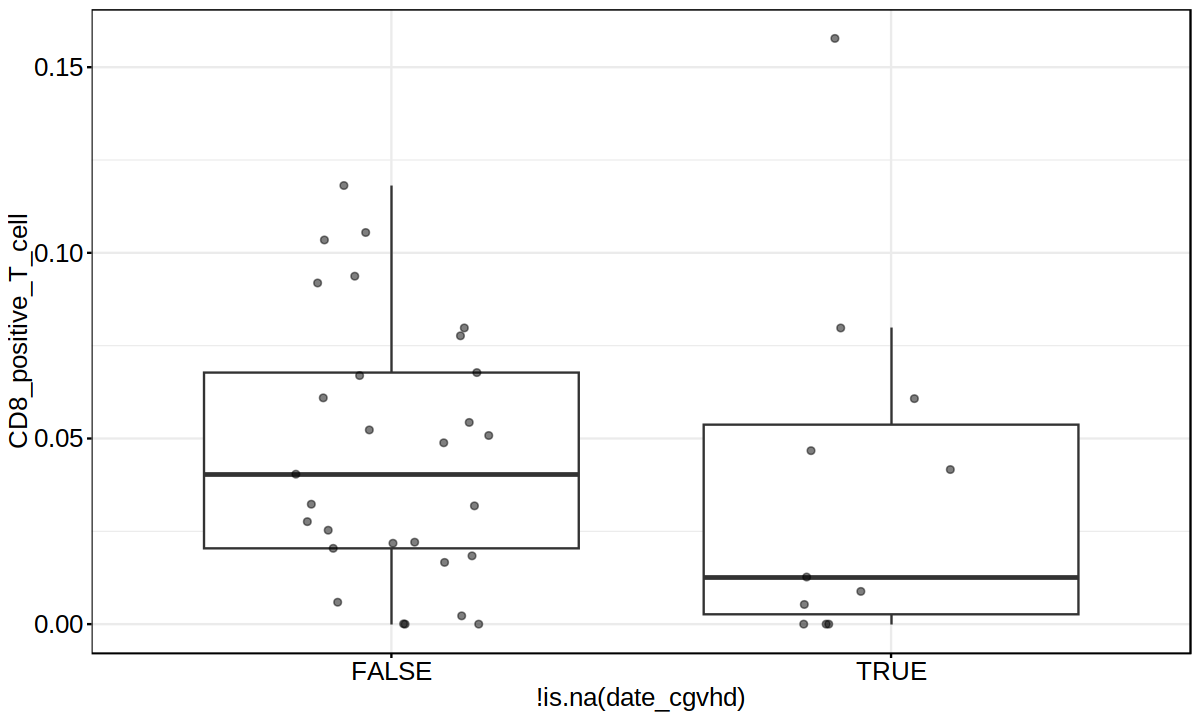

In [64]:
VAR = "memory_B_cell"
VAR = "CD8_positive_T_cell"


mdf_Nm %>% 
    ggplot(aes(x=!is.na(date_cgvhd), y=!!sym(VAR))) +
    geom_boxplot(outlier.shape = NA) +
    geom_jitter(width = 0.2, alpha = 0.5, height = 0) +
    theme_cfrna_slides()

In [581]:
### run corr tests
all_metrics = c(colnames(metrics),colnames(decon))
all_metrics = all_metrics[!all_metrics %in% c("sample_id","Record_ID","timepoint")]

all_res_corr = lapply(all_metrics, function(X) {
    scores= mdf_Nm %>% filter(!is.na(date_cgvhd)) %>% pull(X) %>% as.numeric()
    times = mdf_Nm %>% filter(!is.na(date_cgvhd)) %>% pull(rel_cgvhd) %>% as.numeric()
    res = cor.test(scores,times)
    return(c(X=X, p=res$p.value, cor=res$estimate)) }
    )  %>% do.call(rbind, .) %>% as.data.frame()

all_res_corr %>% arrange(p) %>% head(5)

,X,p,cor.cor
,<chr>,<chr>,<chr>
1,salivary_gland_epithelial_cell,0.0205040265311042,-0.683124042064423
2,ionocyte,0.0346795334693131,-0.637978738621525
3,gland_ductal_epithelial_cell,0.0514588829282864,-0.599069689328822
4,neutrophil_CBC,0.0553882378537766,-0.591271368661803
5,intestinal_secretory_epithelial_cell,0.066144030984381,0.57169274437629


In [582]:
all_res_corr %>% filter(cor.cor >0) %>% arrange(p) %>% head(15)

,X,p,cor.cor
,<chr>,<chr>,<chr>
1,intestinal_secretory_epithelial_cell,0.066144030984381,0.57169274437629
2,conjunctival_epithelial_cell,0.110603819661056,0.508030006946223
3,kidney_parietal_epithelial_cell,0.11943436931412,0.49751325524181
4,leukocyte_activity,0.14880995064947,0.465741182296816
5,CD8_positive_T_cell,0.170706537194371,0.444548924012389
6,mesenchymal_and_stromal_cell,0.300074710058504,0.344126467103138
7,vascular_endothelial_cell,0.31712336997637,0.332914557133349
8,lymphocyte_activity,0.317696265483058,0.332543535628211
9,immature_B_cell,0.329546726433412,0.324947882909271


Warning message:
“Removed 29 rows containing missing values or values outside the scale range
(`geom_point()`).”


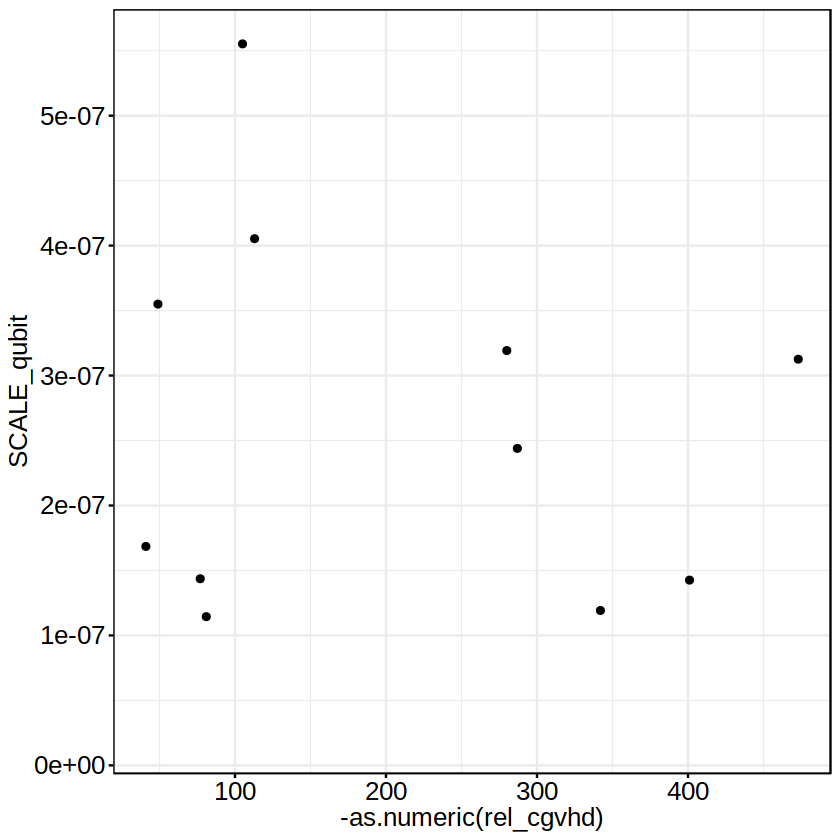

In [594]:
VAR = "leukocyte_activity"
VAR = "CD8_positive_T_cell"
VAR = "SCALE_qubit"

mdf_Nm %>% 
    ggplot(aes(x=-as.numeric(rel_cgvhd), y=!!sym(VAR))) +
    geom_point()+
    theme_cfrna_slides()

---
## MCC post

In [617]:
TIME = c("taper_end")

### load data and merge
metrics = read.delim("../1_DATA/metrics_passQC.tsv") %>% unique()
decon = read.delim("../1_DATA/decon_passQC.new.tsv")

# ### Scale decon
# qbits = metrics %>% remove_rownames() %>% select(sample_id, SCALE_qubit) %>% column_to_rownames(.,"sample_id")
# decon = decon %>% remove_rownames() %>% column_to_rownames(.,"sample_id")
# decon = decon[rownames(qbits),]
# decon = decon * qbits$SCALE_qubit
# decon = decon %>% rownames_to_column("sample_id")


mdf_Nm = read.delim("../1_DATA/sample_meta_passQC.tsv") %>% 
    filter(timepoint %in% TIME) %>% 
    select(!SCALE_qubit) %>% 
    mutate(rel_cgvhd = ymd(date) - ymd(date_cgvhd))

mdf_Nm <- merge(mdf_Nm, metrics, by="sample_id")
mdf_Nm <- merge(mdf_Nm, decon, by="sample_id") %>% unique()
 
print(table(is.na(mdf_Nm$date_cgvhd)))


FALSE  TRUE 
    7    14 


In [618]:
### run wilcoxon tests
all_metrics = c(colnames(metrics),colnames(decon))
all_metrics = all_metrics[!all_metrics %in% c("sample_id","Record_ID","timepoint")]

all_res_wilcox = lapply(all_metrics, function(X) {
    g1= mdf_Nm %>% filter(is.na(date_cgvhd)) %>% pull(X) %>% as.numeric()
    g2= mdf_Nm %>% filter(!is.na(date_cgvhd)) %>% pull(X) %>% as.numeric()
    FC= median(g2) / median(g1)
    res = wilcox.test(g1,g2)
    return(c(X=X, p=res$p.value, fc = FC)) }
    )  %>% do.call(rbind, .) %>% as.data.frame()

all_res_wilcox$fc = as.numeric(all_res_wilcox$fc)

all_res_wilcox %>% arrange(p) %>% head(5)

Warning message in wilcox.test.default(g1, g2):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(g1, g2):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(g1, g2):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(g1, g2):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(g1, g2):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(g1, g2):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(g1, g2):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(g1, g2):
“cannot compute exact p-value with ties”


,X,p,fc
,<chr>,<chr>,<dbl>
1,memory_B_cell,0.000120399036807706,1.485407e+00
2,intrahepatic_cholangiocyte,0.000515995872033024,1.470226e+00
3,leukocyte_decon,0.000773993808049536,1.261979e+00
4,intermediate_monocyte,0.00113519091847265,3.041519e-17
5,Pegivirus_CPM,0.00161678706570347,1.470164e-02


In [619]:
all_res_wilcox %>% filter(fc > 1) %>% arrange(p) %>% head(10)

,X,p,fc
,<chr>,<chr>,<dbl>
1,memory_B_cell,0.000120399036807706,1.485407e+00
2,intrahepatic_cholangiocyte,0.000515995872033024,1.470226e+00
3,leukocyte_decon,0.000773993808049536,1.261979e+00
4,dendritic_cell,0.0022703818369453,4.720345e+00
5,common_lymphoid_progenitor,0.0249570003439972,2.361617e+16
6,classical_monocyte,0.030890952872377,3.313896e+00
7,pancreatic_acinar_epithelial_cell,0.030890952872377,1.910541e+00
8,monocyte_activity,0.0378740970072239,3.769761e+00
9,lymphocyte_decon,0.0937736498108015,1.219881e+00


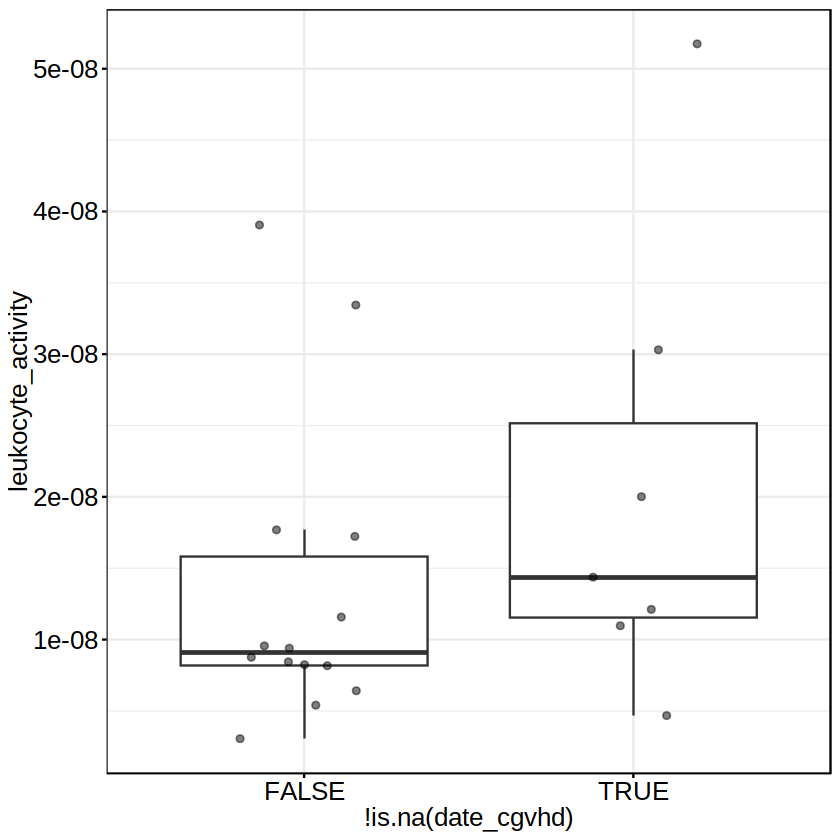

In [624]:
VAR = "memory_B_cell"
VAR = "leukocyte_activity"


mdf_Nm %>% 
    ggplot(aes(x=!is.na(date_cgvhd), y=!!sym(VAR))) +
    geom_boxplot(outlier.shape = NA) +
    geom_jitter(width = 0.2, alpha = 0.5, height = 0) +
    theme_cfrna_slides()

In [625]:
### run corr tests
all_metrics = c(colnames(metrics),colnames(decon))
all_metrics = all_metrics[!all_metrics %in% c("sample_id","Record_ID","timepoint")]

all_res_corr = lapply(all_metrics, function(X) {
    scores= mdf_Nm %>% filter(!is.na(date_cgvhd)) %>% pull(X) %>% as.numeric()
    times = mdf_Nm %>% filter(!is.na(date_cgvhd)) %>% pull(rel_cgvhd) %>% as.numeric()
    res = cor.test(scores,times)
    return(c(X=X, p=res$p.value, cor=res$estimate)) }
    )  %>% do.call(rbind, .) %>% as.data.frame()

all_res_corr %>% arrange(p) %>% head(5)

,X,p,cor.cor
,<chr>,<chr>,<chr>
1,erythroblast,0.00098776630507833,0.951127255065291
2,pancreatic_acinar_epithelial_cell,0.00121372998504162,0.946880238514526
3,pancreatic_stellate_cell,0.00131739626939513,0.945088446057133
4,monocyte_decon,0.00178773921445196,-0.937857972380536
5,classical_monocyte,0.0029230839945905,-0.924123153971517


In [626]:
all_res_corr %>% filter(cor.cor >0) %>% arrange(p) %>% head(15)

,X,p,cor.cor
,<chr>,<chr>,<chr>
1,erythroblast,0.00098776630507833,0.951127255065291
2,pancreatic_acinar_epithelial_cell,0.00121372998504162,0.946880238514526
3,pancreatic_stellate_cell,0.00131739626939513,0.945088446057133
4,CD8_positive_T_cell,0.00360349875562662,0.91737568446455
5,conjunctival_epithelial_cell,0.00725311554798132,0.890033904072652
6,pancreatic_endocrine_epithelial_cell,0.0356833072987118,0.787101734944523
7,innate_like_T_cell,0.0365809925624488,0.78486411557296
8,rbc_CBC,0.0412367214507666,0.77372034683131
9,common_myeloid_progenitor,0.0487823891296298,0.757046452271579


Warning message:
“Removed 14 rows containing missing values or values outside the scale range
(`geom_point()`).”


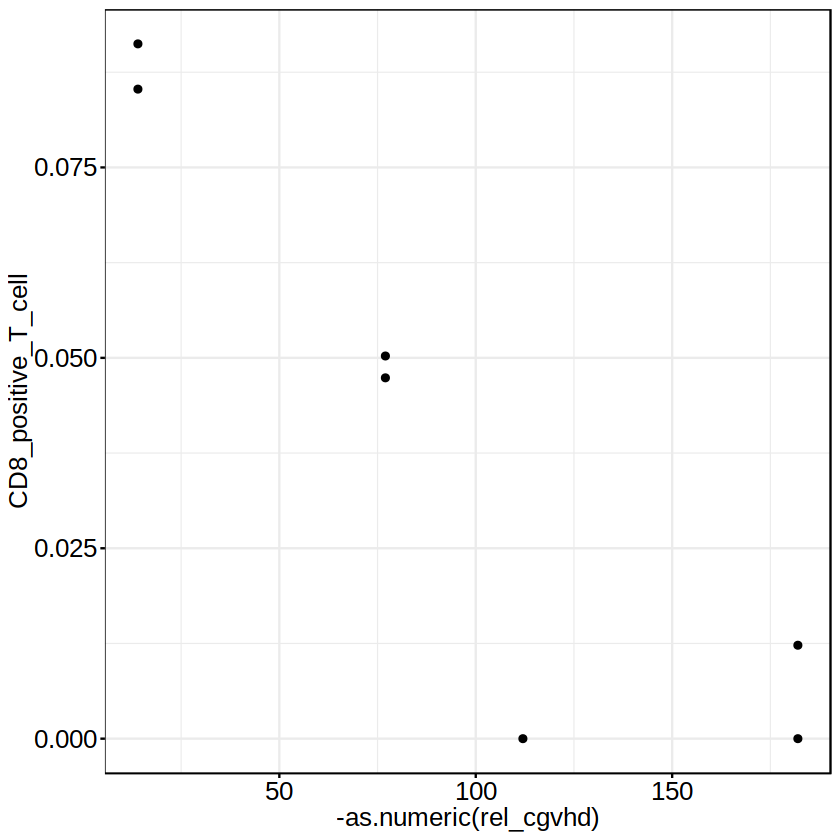

In [630]:
VAR = "leukocyte_activity"
VAR = "CD8_positive_T_cell"

mdf_Nm %>% 
    ggplot(aes(x=-as.numeric(rel_cgvhd), y=!!sym(VAR))) +
    geom_point()+
    theme_cfrna_slides()

---
## moffitt CD8+ Tcell

In [641]:
TIME = c("taper_start","taper_end","wk2_pt","mo1_pt","mo3_pt","mo6_pt")

### load data and merge
metrics = read.delim("../1_DATA/metrics_passQC.tsv") %>% unique()
decon = read.delim("../1_DATA/decon_passQC.new.tsv")

# ### Scale decon
# qbits = metrics %>% remove_rownames() %>% select(sample_id, SCALE_qubit) %>% column_to_rownames(.,"sample_id")
# decon = decon %>% remove_rownames() %>% column_to_rownames(.,"sample_id")
# decon = decon[rownames(qbits),]
# decon = decon * qbits$SCALE_qubit
# decon = decon %>% rownames_to_column("sample_id")


mdf_Nm = read.delim("../1_DATA/sample_meta_passQC.tsv") %>% 
    filter(timepoint %in% TIME) %>% 
    select(!SCALE_qubit) %>% 
    mutate(rel_cgvhd = ymd(date) - ymd(date_cgvhd)) %>% 
    mutate(rel_taper = ymd(date)- ymd(date_taper_start))

mdf_Nm <- merge(mdf_Nm, metrics, by="sample_id")
mdf_Nm <- merge(mdf_Nm, decon, by="sample_id") %>% unique()
 
print(table(is.na(mdf_Nm$date_cgvhd)))


FALSE  TRUE 
   23    55 


In [640]:
mdf_Nm %>% head

,sample_id,Record_ID,date,timepoint,sample_group,all_comps,transplant_date,date_taper_start,date_taper_end,date_agvhd,⋯,pancreatic_ductal_cell,pancreatic_endocrine_epithelial_cell,pancreatic_stellate_cell,plasma_cell,platelet,prostate_epithelial_cell,pulmonary_alveolar_type_1_cell,regulatory_T_cell,salivary_gland_epithelial_cell,plasmablast
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,MCC17948_cfRNA_1_bp61x61,MCC_1,2015-10-12,taper_start,COMP,_cgvhd,2014-09-30,2015-10-12,2016-05-18,NA,⋯,1.799872e-04,4.233094e-19,6.019041e-03,1.363491e-16,0.06544229,1.662300e-05,1.061714e-19,3.194706e-19,1.267128e-19,3.269247e-19
2,MCC17948_cfRNA_13_bp61x61,MCC_11,2016-02-24,taper_start,noCOMP,,2014-02-20,2016-02-24,2017-02-15,NA,⋯,7.497713e-05,4.410565e-19,2.725554e-19,3.677829e-19,0.09567626,5.713417e-05,1.086323e-19,2.219956e-04,1.351931e-19,7.688155e-04
3,MCC17948_cfRNA_14_bp61x61,MCC_11,2017-02-15,taper_end,noCOMP,,2014-02-20,2016-02-24,2017-02-15,NA,⋯,3.600619e-04,4.423552e-19,1.977845e-02,3.707495e-19,0.11370300,1.355278e-19,1.079096e-19,2.963432e-04,5.103102e-06,1.373188e-12
4,MCC17948_cfRNA_15_bp61x61,MCC_13,2016-05-16,taper_start,noCOMP,,2015-10-02,2016-05-16,2017-02-27,NA,⋯,1.688837e-03,4.098388e-19,2.563336e-19,4.288248e-03,0.10413101,1.247928e-19,2.164488e-04,1.029798e-10,1.284941e-19,2.181550e-03
5,MCC17948_cfRNA_16_bp61x61,MCC_13,2017-02-27,taper_end,noCOMP,,2015-10-02,2016-05-16,2017-02-27,NA,⋯,6.634295e-04,4.068317e-19,3.860057e-04,3.430183e-19,0.05760017,6.522526e-05,1.098394e-04,3.029832e-19,1.229988e-19,1.732394e-03
6,MCC17948_cfRNA_17_bp61x61,MCC_14,2016-05-16,taper_start,COMP,_cgvhd,2011-11-15,2016-05-16,NA,NA,⋯,7.778387e-05,3.500233e-19,1.214683e-03,2.264848e-15,0.02815291,4.985956e-05,2.149844e-07,2.153163e-02,1.057965e-19,3.916054e-04


Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_line()`).”


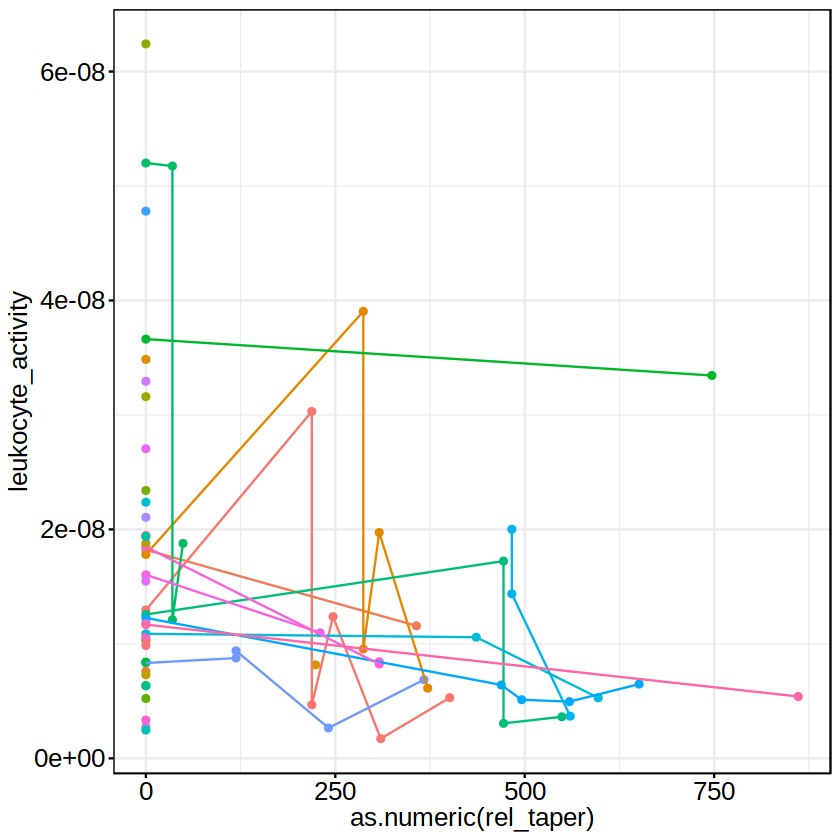

In [643]:
VAR = "leukocyte_activity"
mdf_Nm %>% 
    ggplot(aes(x=as.numeric(rel_taper), y=.data[[VAR]],group=Record_ID, color = Record_ID)) +
    geom_point()+
    geom_line()+
    theme_cfrna_slides()

---
---
## Explore

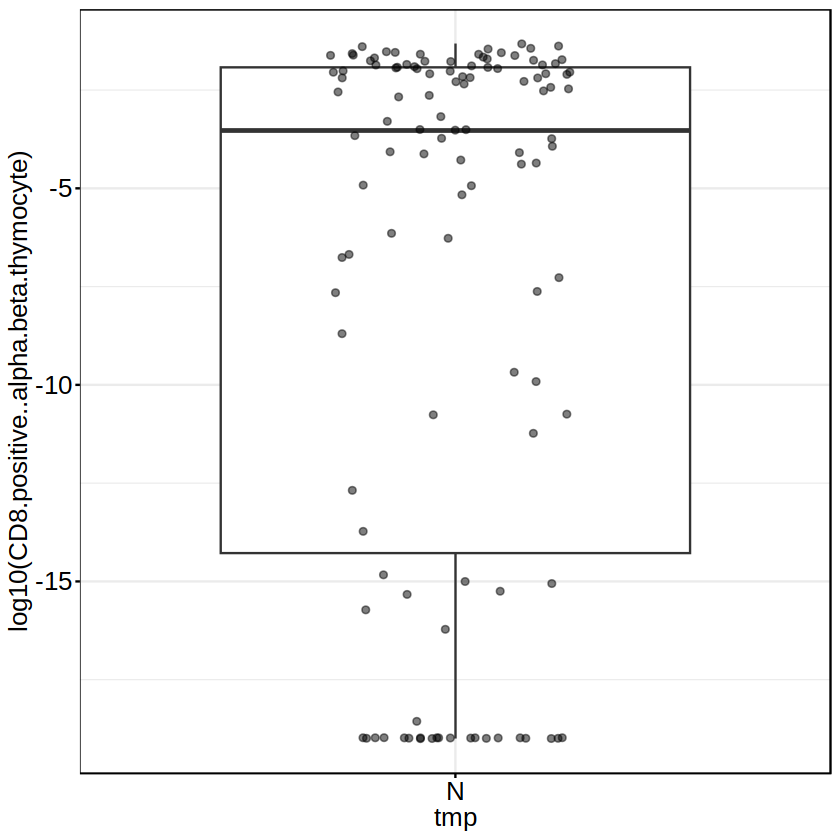

In [195]:
mdf_Nm %>% 
    mutate(tmp = "N") %>% 
    ggplot(aes(x=tmp, y=log10(CD8.positive..alpha.beta.thymocyte)))+
    geom_boxplot() +
    geom_jitter(width = 0.2, alpha = 0.5, height = 0) +
    theme_cfrna_slides()

In [205]:
low_colon = mdf_Nm %>% filter(colon.endothelial.cell < 1e-5) %>% filter(!is.na(cGVHD_date))
low_cd8 = mdf_Nm %>% filter(CD8.positive..alpha.beta.thymocyte < 1e-5) %>% filter(!is.na(cGVHD_date))


In [209]:
low_colon %>% nrow()
low_cd8 %>% nrow()

low_colon$platelet %>% summary()
low_cd8$platelet %>% summary()
mdf_Nm$platelet %>% summary()

[1] 28

[1] 25

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.02506 0.28292 0.42641 0.44059 0.59653 0.72910 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.02506 0.18080 0.25934 0.27407 0.34922 0.61691 

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
0.006182 0.280991 0.401562 0.392432 0.524880 0.729104 

In [170]:
low_colon %>% head()

,sample_id,Record_ID,timepoint,date,transplant_date,rel_transplant,aGVHD,aGVHD_date,cGVHD,cGVHD_date,⋯,pancreatic.ductal.cell,pancreatic.endocrine.epithelial.cell,pancreatic.stellate.cell,plasma.cell,platelet,prostate.epithelial.cell,pulmonary.alveolar.type.1.cell,regulatory.T.cell,salivary.gland.epithelial.cell,plasmablast
,<chr>,<chr>,<fct>,<date>,<date>,<drtn>,<lgl>,<date>,<lgl>,<date>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,gvhd_hct_cfrna_143_bp61x61,50,3M,2019-03-06,2018-12-04,92 days,FALSE,NA,TRUE,2019-06-05,⋯,3.220095e-12,4.915883e-06,2.093318e-19,4.009050e-16,0.7036277,1.581678e-05,9.694459e-20,5.606497e-05,1.272152e-06,3.020585e-19
2,gvhd_hct_cfrna_18_bp51x51,26,3M,2018-12-10,2018-09-12,89 days,FALSE,NA,TRUE,2019-10-07,⋯,2.207878e-19,2.103594e-06,2.143840e-19,1.822163e-15,0.4101137,1.916728e-05,3.421592e-04,3.458337e-02,9.142358e-20,3.109346e-19
3,gvhd_hct_cfrna_19_bp51x51,26,6M,2019-03-11,2018-09-12,180 days,FALSE,NA,TRUE,2019-10-07,⋯,2.083851e-19,1.554952e-05,2.034380e-19,5.718297e-03,0.2179960,1.110446e-19,5.083830e-16,6.174664e-02,2.500483e-05,3.006133e-19
4,gvhd_hct_cfrna_191_bp61x61,36,3M,2019-01-14,2018-10-17,89 days,FALSE,NA,TRUE,2020-02-24,⋯,1.990886e-19,1.512617e-19,1.992127e-19,1.912186e-12,0.6169057,1.904782e-05,8.948961e-13,7.272014e-04,1.075800e-19,6.446806e-05
5,gvhd_hct_cfrna_197_bp61x61,36,6M,2019-04-11,2018-10-17,176 days,FALSE,NA,TRUE,2020-02-24,⋯,5.979068e-06,2.305274e-06,2.723991e-05,1.637851e-10,0.5701548,4.703352e-05,2.066631e-13,1.222613e-02,2.761531e-06,3.075483e-19
6,gvhd_hct_cfrna_218_bp61x61,40,3M,2019-01-29,2018-10-25,96 days,FALSE,NA,TRUE,2019-04-18,⋯,6.410301e-13,1.848814e-19,3.132474e-06,3.271663e-19,0.7291041,9.420915e-07,3.175468e-17,2.820212e-19,7.789803e-20,2.978475e-19
